<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/MONTESDEOCA-ANDRES-DL-TP2-Co24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 24 - 2do bimestre 2026

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## Data Load

In [1]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm
import seaborn as sns
import gdown
import copy

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

custom_palette = {'<=50K': '#ff9999', '>50K': '#add8e6'}

In [2]:
# Enlace a la carpeta de Google Drive
folder_url = 'https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln'

# Descargar la carpeta completa en un directorio específico llamado 'dataset'
print("Descargando archivos desde Google Drive...")
gdown.download_folder(folder_url, output='dataset', quiet=True, use_cookies=False)

# Cargar los archivos directamente en las variables train y test
train = pd.read_csv('dataset/adult_train.csv')
test = pd.read_csv('dataset/adult_val.csv')

# Lista de Series transofrmadas, listas para entrenar
variables_transformadas_train = []
variables_transformadas_test  = []

Descargando archivos desde Google Drive...


## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [3]:
# Train

print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   education       30162 non-null  object
 3   marital-status  30162 non-null  object
 4   occupation      30162 non-null  object
 5   relationship    30162 non-null  object
 6   race            30162 non-null  object
 7   sex             30162 non-null  object
 8   capital-gain    30162 non-null  int64 
 9   capital-loss    30162 non-null  int64 
 10  hours-per-week  30162 non-null  int64 
 11  skill-profile   30162 non-null  object
 12  native-country  30162 non-null  object
 13  income          30162 non-null  object
dtypes: int64(4), object(10)
memory usage: 3.2+ MB
None


In [4]:
# Test

print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15060 entries, 0 to 15059
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             15060 non-null  int64 
 1   workclass       15060 non-null  object
 2   education       15060 non-null  object
 3   marital-status  15060 non-null  object
 4   occupation      15060 non-null  object
 5   relationship    15060 non-null  object
 6   race            15060 non-null  object
 7   sex             15060 non-null  object
 8   capital-gain    15060 non-null  int64 
 9   capital-loss    15060 non-null  int64 
 10  hours-per-week  15060 non-null  int64 
 11  skill-profile   15060 non-null  object
 12  native-country  15060 non-null  object
 13  income          15060 non-null  object
dtypes: int64(4), object(10)
memory usage: 1.6+ MB
None


- 30K registros en Train y 15K resitros en Test
- No hay nulos

### Income (Target)
Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

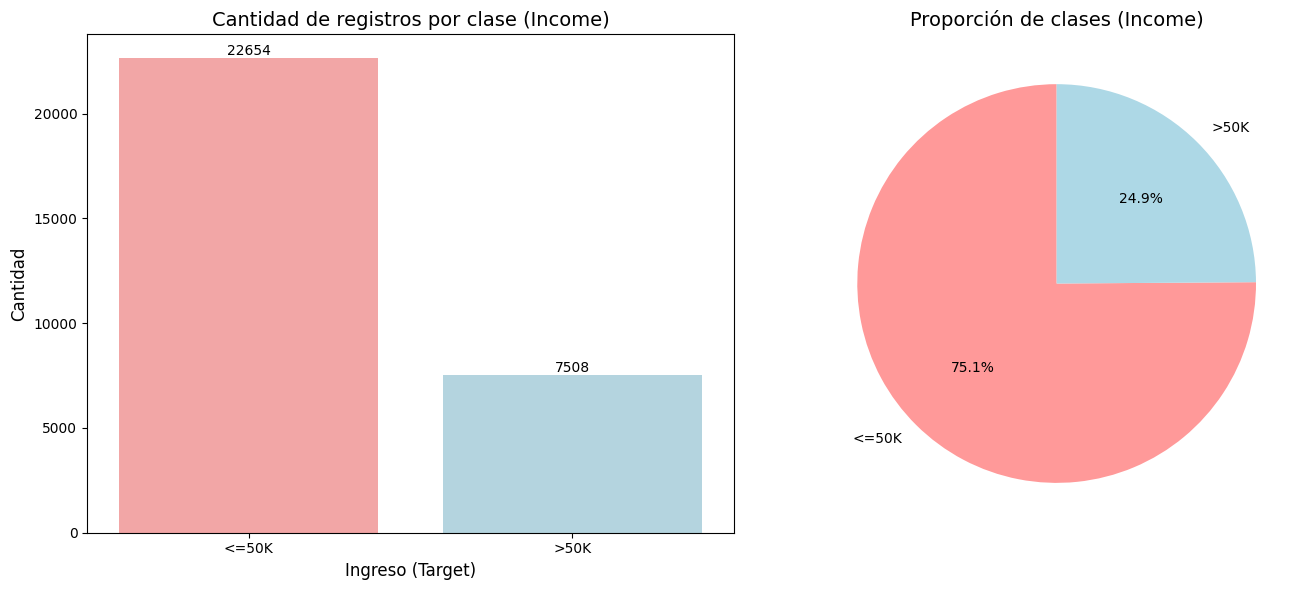

In [5]:
# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de barras (Countplot)
# Se agrega hue='income' y legend=False para evitar el FutureWarning de Seaborn
sns.countplot(data=train, x='income', ax=axes[0], hue='income', palette=custom_palette, legend=False)
axes[0].set_title('Cantidad de registros por clase (Income)', fontsize=14)
axes[0].set_xlabel('Ingreso (Target)', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)

# Agregar los valores exactos sobre las barras
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Gráfico de torta (Pie chart)
income_counts = train['income'].value_counts()
# Mapeamos los colores desde custom_palette respetando el orden del índice
pie_colors = [custom_palette[val] for val in income_counts.index]
axes[1].pie(income_counts, labels=income_counts.index, autopct='%1.1f%%', startangle=90, colors=pie_colors)
axes[1].set_title('Proporción de clases (Income)', fontsize=14)

plt.tight_layout()
plt.show()

- Defino la Clase Positiva como >50K
- Un poco desbalanceada 25%

In [6]:
# 1. Transformación Variable Target (Income) -> BOOL_Income

target_mapping = {'<=50K': 0, '>50K': 1}

BOOL_Income_train = train['income'].map(target_mapping).astype(int)
BOOL_Income_test = test['income'].map(target_mapping).astype(int)

# Asignamos el nombre a la serie para consistencia
BOOL_Income_train.name = 'BOOL_Income'
BOOL_Income_test.name = 'BOOL_Income'


- Transformo el Target a INT 0/1 para el entrenamiento del modelo
- BOOL_Income

### Age
Edad del individuo expresada en años.

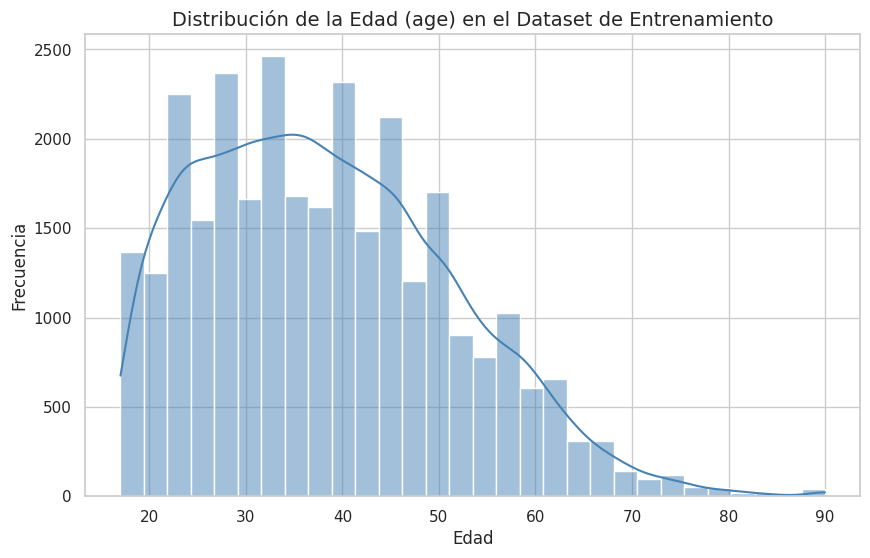


Estadísticas descriptivas de la variable 'age':


,age
count,30162.000000
mean,38.437902
std,13.134665
min,17.000000
25%,28.000000
50%,37.000000
75%,47.000000
max,90.000000


In [7]:
# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear el histograma para la variable 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=train, x='age', bins=30, kde=True, color='steelblue')
plt.title('Distribución de la Edad (age) en el Dataset de Entrenamiento', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

# Mostrar estadísticas descriptivas de la variable 'age'
print("\nEstadísticas descriptivas de la variable 'age':")
display(train['age'].describe())

- Distribucion bastante simetrica centrada en 38/37 años (media/mediana)
- Arranca en 17 y termina en 90. Talvez se pueda capear los valores maximos?

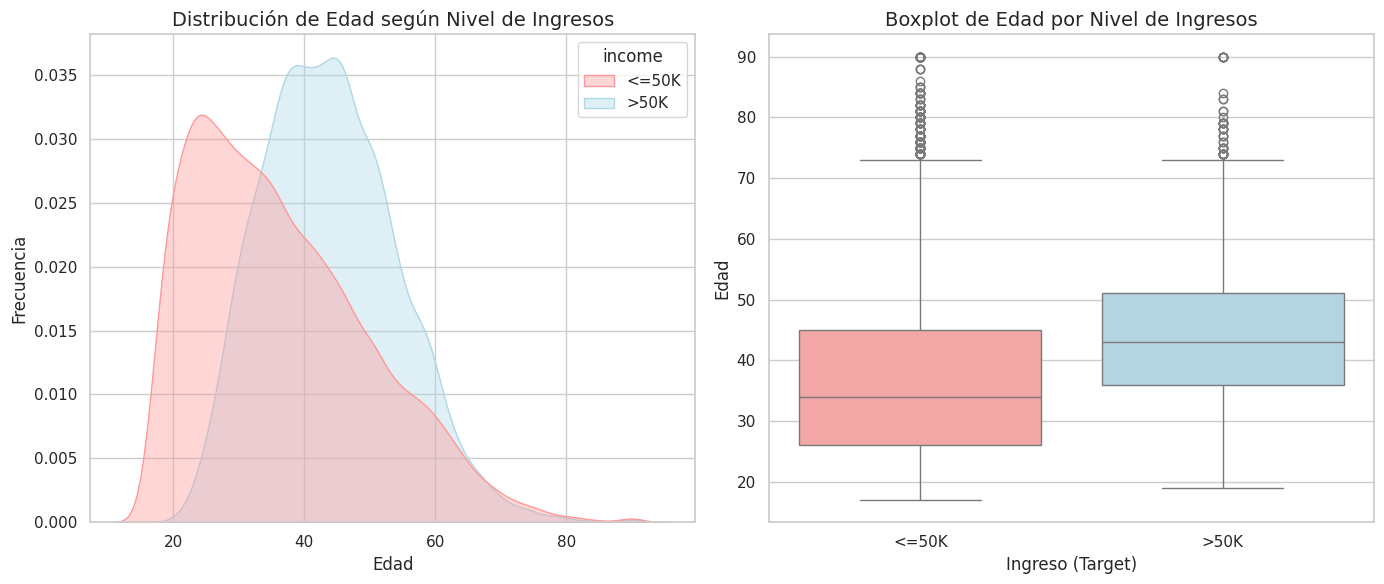

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,22654.0,36.60806,13.464631,17.0,26.0,34.0,45.0,90.0
>50K,7508.0,43.95911,10.269633,19.0,36.0,43.0,51.0,90.0


In [8]:
# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Histograma superpuesto por clase (Income)
sns.kdeplot(
    data=train, x='age', hue='income',
    hue_order=['<=50K', '>50K'],
    ax=axes[0],
    palette=custom_palette,
    fill=True,
    alpha=0.4,
    common_norm=False
)
axes[0].set_title('Distribución de Edad según Nivel de Ingresos', fontsize=14)
axes[0].set_xlabel('Edad', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# 2. Boxplot de Edad por clase (Income)
# Se asigna hue='income' y legend=False para evitar warnings de seaborn
sns.boxplot(data=train, x='income', y='age', hue='income', ax=axes[1], palette=custom_palette, legend=False)
axes[1].set_title('Boxplot de Edad por Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Ingreso (Target)', fontsize=12)
axes[1].set_ylabel('Edad', fontsize=12)

plt.tight_layout()
plt.show()

display(train.groupby('income')['age'].describe())


- Se observa como la distribucion de la edad para el segmento de mayores ingresos es mas simetrica y centrada en 43 años, considerablmente mayor a la distribucion del Universo

In [9]:
# 2. Transformación Age -> SCA_age
upper_limit = train['age'].quantile(0.99)

# Aplicamos clipping
age_train_clipped = train['age'].clip(upper=upper_limit).values.reshape(-1, 1)
age_test_clipped = test['age'].clip(upper=upper_limit).values.reshape(-1, 1)

scaler_age = MinMaxScaler()

# Guardamos como Series independientes con el nuevo nombre SCA_age
SCA_age_train = pd.Series(scaler_age.fit_transform(age_train_clipped).flatten(), index=train.index, name='SCA_age')
SCA_age_test = pd.Series(scaler_age.transform(age_test_clipped).flatten(), index=test.index, name='SCA_age')

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(SCA_age_train)
variables_transformadas_test.append(SCA_age_test)

display(SCA_age_train.describe())


,SCA_age
count,30162.000000
mean,0.388678
std,0.235509
min,0.000000
25%,0.200000
50%,0.363636
75%,0.545455
max,1.000000


- Capeamos al percentil 99 para limitar el impacto que puedan ocacionar los registros con valores extremos (gente de 90 años)
- Ya que la idea es utilizar una Red Neuronal, y que sabemos que no hay valores exteremos, Escalamos los datos entre 0 y 1 utilizando MinMax Scaler
- SCA_age

### Workclass
Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

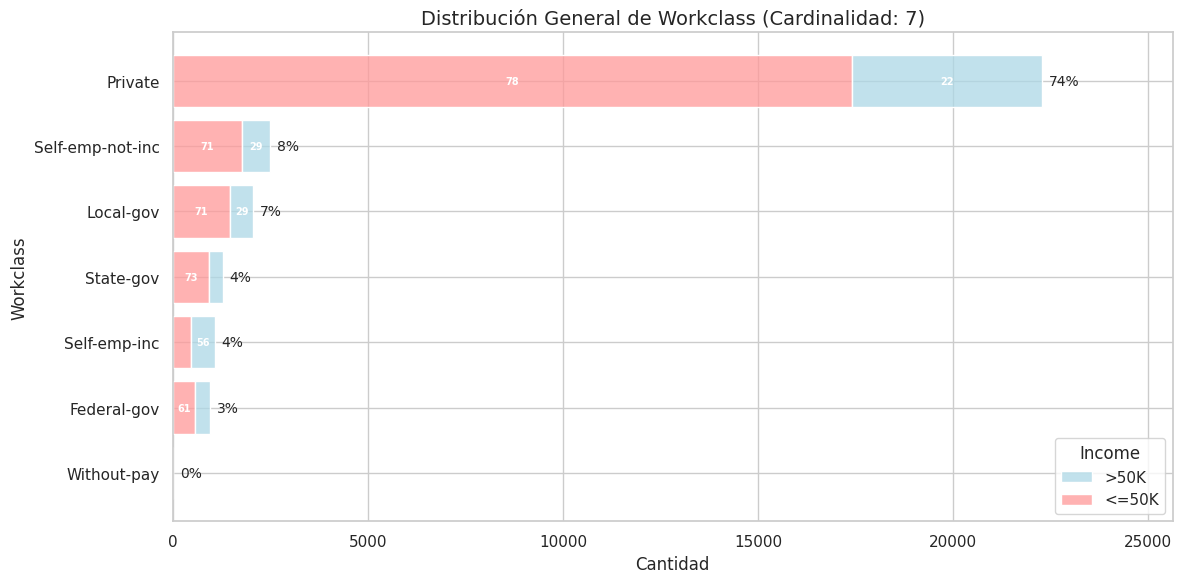

In [10]:
cardinalidad_workclass = train['workclass'].nunique()
conteo_workclass = train['workclass'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos temporalmente para el gráfico
train['workclass'] = pd.Categorical(train['workclass'], categories=conteo_workclass.index, ordered=True)

sns.histplot(data=train, y='workclass', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Workclass (Cardinalidad: {cardinalidad_workclass})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Workclass', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_workclass.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_workclass):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra) con el umbral del 2%
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_workclass.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['workclass'] = train['workclass'].astype(object)
plt.tight_layout()
plt.show()

- Carnilaidad de 7: Probar one-hot y embeddings
- La gran mayoría de las personas trabajan en el sector privado
- Proporcionalmente, los trabajadores independientes registrados y los federales, son los que tienen un mayor salario
- Creamos categoria Others???? Que hacemos con "Without-pay"???

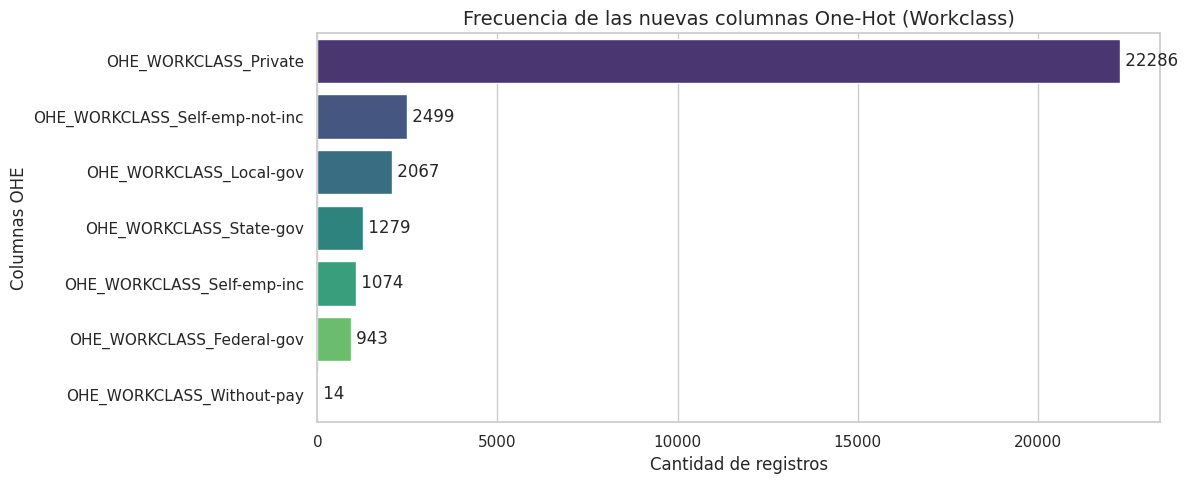

In [11]:
# 3. Transformación Workclass -> OHE_workclass
# Instanciamos el encoder
ohe_workclass = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos con train y transformamos ambos
workclass_ohe_train_raw = ohe_workclass.fit_transform(train[['workclass']])
workclass_ohe_test_raw = ohe_workclass.transform(test[['workclass']])

# Obtenemos las categorías originales para nombrar las columnas con el prefijo OHE_WORKCLASS_
categories = [cat.replace(' ', '_') for cat in ohe_workclass.categories_[0]]
columns_ohe = [f"OHE_WORKCLASS_{cat}" for cat in categories]

# Creamos los DataFrames resultantes
OHE_workclass_train = pd.DataFrame(workclass_ohe_train_raw, columns=columns_ohe, index=train.index)
OHE_workclass_test = pd.DataFrame(workclass_ohe_test_raw, columns=columns_ohe, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_workclass_train)
variables_transformadas_test.append(OHE_workclass_test)

# Plotemaos las transformaciones
plt.figure(figsize=(12, 5))
ohe_counts = OHE_workclass_train.sum().sort_values(ascending=False)
sns.barplot(x=ohe_counts.values, y=ohe_counts.index, hue=ohe_counts.index, palette='viridis', legend=False)
plt.title('Frecuencia de las nuevas columnas One-Hot (Workclass)', fontsize=14)
plt.xlabel('Cantidad de registros', fontsize=12)
plt.ylabel('Columnas OHE', fontsize=12)

# Agregar anotaciones numéricas
for index, value in enumerate(ohe_counts.values):
    plt.text(value, index, f' {int(value)}', va='center')

plt.tight_layout()
plt.show()


- Cardinlaidad baja y no ordinal, transformamos con One-Hot encoding
- OHE_WORKCLASS_xxx


### Education
Nivel educativo alcanzado del individuo.

In [12]:
# Renombramos para que incluya el valor ordinal de cada categoria, para simplicar la comprension en las visualizaciones

education_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']
education_mapping = {edu: f'{i+1:02d}-{edu}' for i, edu in enumerate(education_order)}

# Aplicamos el mapeo ordinal
train['education'] = train['education'].map(education_mapping)
test['education'] = test['education'].map(education_mapping)

# Definimos el orden para los graficos basado en los nuevos strings
order_edu = sorted(train['education'].unique())
cardinalidad_edu = train['education'].nunique()

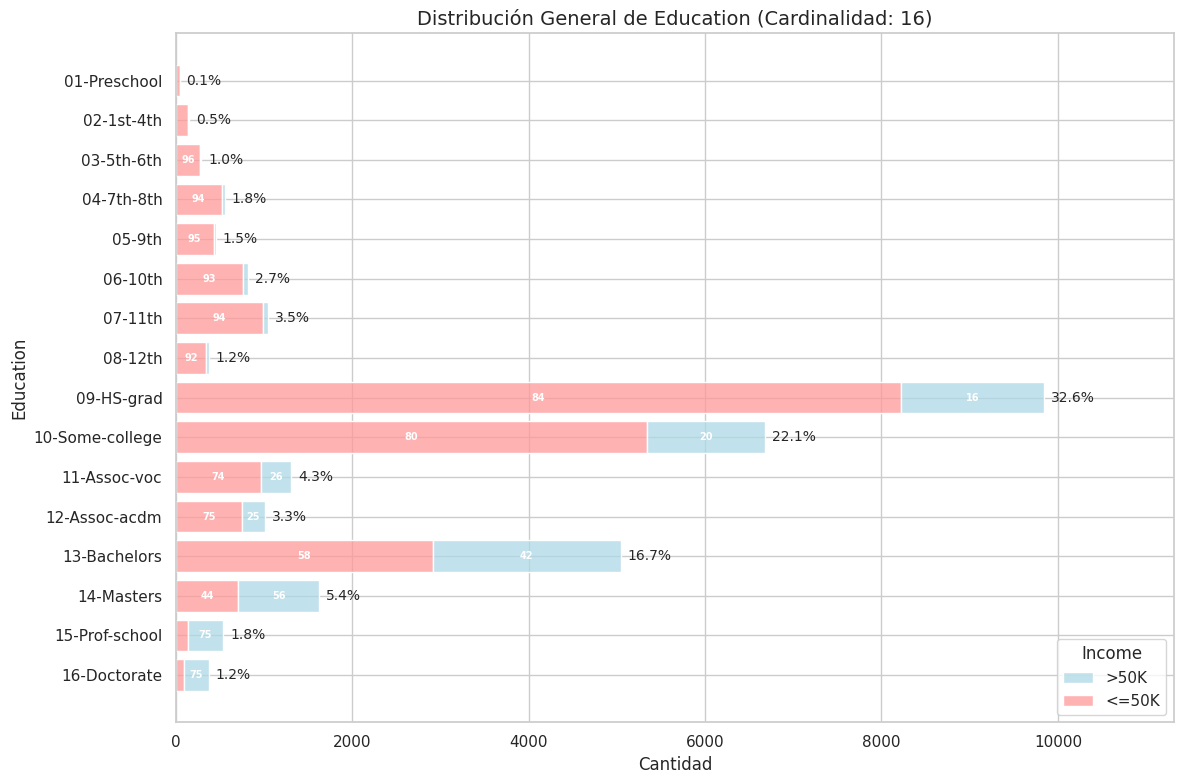

In [13]:
# Ploteo

conteo_education = train['education'].value_counts().reindex(order_edu)
fig, ax = plt.subplots(figsize=(12, 8))
train['education'] = pd.Categorical(train['education'], categories=order_edu, ordered=True)

sns.histplot(data=train, y='education', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Education (Cardinalidad: {cardinalidad_edu})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Education', fontsize=12)

sns.move_legend(ax, 'lower right', title='Income')

# Anotaciones externas (% del total)
ax.set_xlim(0, conteo_education.max() * 1.15)
total_records = len(train)
for i, width in enumerate(conteo_education):
    percentage = f'{100 * width / total_records:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Anotaciones internas (% de la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_education):
            total_bar = conteo_education.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

train['education'] = train['education'].astype(object)
plt.tight_layout()
plt.show()

- Cardinlaidad de 16: Podemos usar Embeddings o agruparlas y usar Ordinal
- Se ve claramente que los profesionales con titulo universitario tienen una mayor distribucion de ingresos

In [14]:
# Agrupamos y Transoformamos

# Reagrupamos las categorías de education según lo solicitado (cubriendo ambas opciones)
group_mapping = {
    'Preschool': '01 - Primary',
    '1st-4th': '01 - Primary',
    '5th-6th': '01 - Primary',
    '7th-8th': '01 - Primary',
    '9th': '02 - HighSchool Incomplete',
    '10th': '02 - HighSchool Incomplete',
    '11th': '02 - HighSchool Incomplete',
    '12th': '02 - HighSchool Incomplete',
    'HS-grad': '03 - HighSchool Complete',
    'Some-college': '04 - Bachelors Incomplete',
    'Assoc-voc': '05 - Associate Complete',
    'Assoc-acdm': '05 - Associate Complete',
    'Bachelors': '06 - Bachelors Complete',
    'Masters': '07 - Masters Complete',
    'Prof-school': '08 - Prof/PhD Complete',
    'Doctorate': '08 - Prof/PhD Complete',
    '01-Preschool': '01 - Primary',
    '02-1st-4th': '01 - Primary',
    '03-5th-6th': '01 - Primary',
    '04-7th-8th': '01 - Primary',
    '05-9th': '02 - HighSchool Incomplete',
    '06-10th': '02 - HighSchool Incomplete',
    '07-11th': '02 - HighSchool Incomplete',
    '08-12th': '02 - HighSchool Incomplete',
    '09-HS-grad': '03 - HighSchool Complete',
    '10-Some-college': '04 - Bachelors Incomplete',
    '11-Assoc-voc': '05 - Associate Complete',
    '12-Assoc-acdm': '05 - Associate Complete',
    '13-Bachelors': '06 - Bachelors Complete',
    '14-Masters': '07 - Masters Complete',
    '15-Prof-school': '08 - Prof/PhD Complete',
    '16-Doctorate': '08 - Prof/PhD Complete'
}

# Aplicamos la agrupación limpiando espacios extras
train['education_grouped'] = train['education'].str.strip().map(group_mapping)
test['education_grouped'] = test['education'].str.strip().map(group_mapping)

# Definimos el nuevo orden
new_order = [
    '01 - Primary',
    '02 - HighSchool Incomplete',
    '03 - HighSchool Complete',
    '04 - Bachelors Incomplete',
    '05 - Associate Complete',
    '06 - Bachelors Complete',
    '07 - Masters Complete',
    '08 - Prof/PhD Complete'
]

# Creamos un mapeo inverso a enteros (0 a 7)
ord_mapping = {val: i for i, val in enumerate(new_order)}

# Aplicamos el ordinal encoding a los grupos
ORD_education_train = train['education_grouped'].map(ord_mapping).astype(int)
ORD_education_test = test['education_grouped'].map(ord_mapping).astype(int)

# Asignamos nombre para consistencia
ORD_education_train.name = 'ORD_education'
ORD_education_test.name = 'ORD_education'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(ORD_education_train)
variables_transformadas_test.append(ORD_education_test)


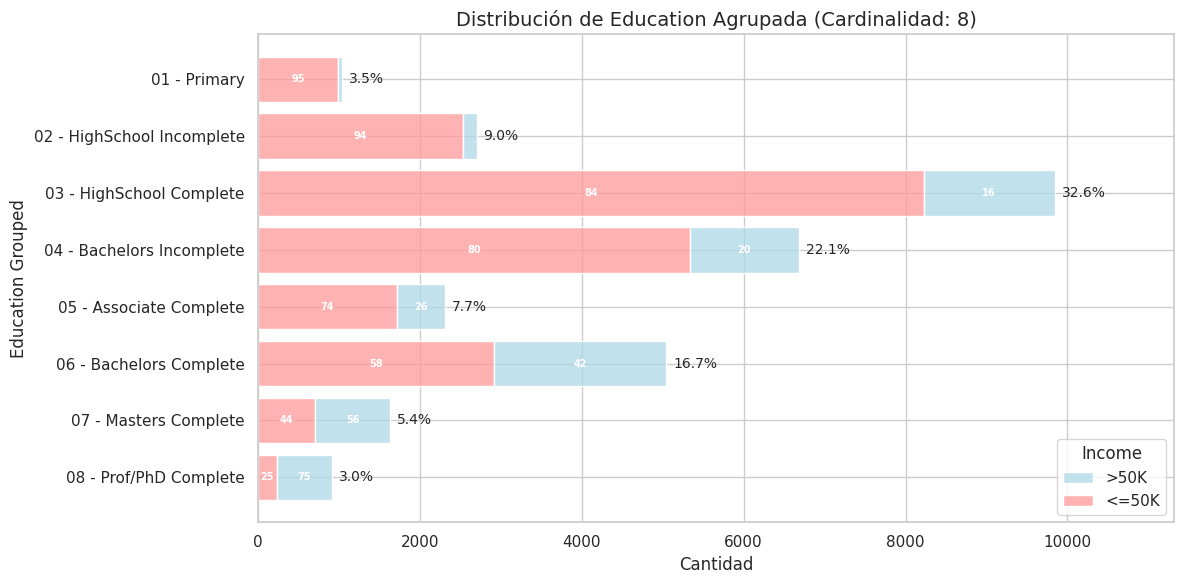

In [15]:
# Ploteamos

cardinalidad_edu_grouped = train['education_grouped'].nunique()
conteo_edu_grouped = train['education_grouped'].value_counts().reindex(new_order)

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos para el gráfico respetando el ordinal
train['education_grouped'] = pd.Categorical(train['education_grouped'], categories=new_order, ordered=True)

sns.histplot(data=train, y='education_grouped', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución de Education Agrupada (Cardinalidad: {cardinalidad_edu_grouped})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Education Grouped', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_edu_grouped.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_edu_grouped):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_edu_grouped):
            total_bar = conteo_edu_grouped.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['education_grouped'] = train['education_grouped'].astype(object)
plt.tight_layout()
plt.show()

- Reagrupando reducimos la cardinalidada a 8 para usar Ordinal Encoder

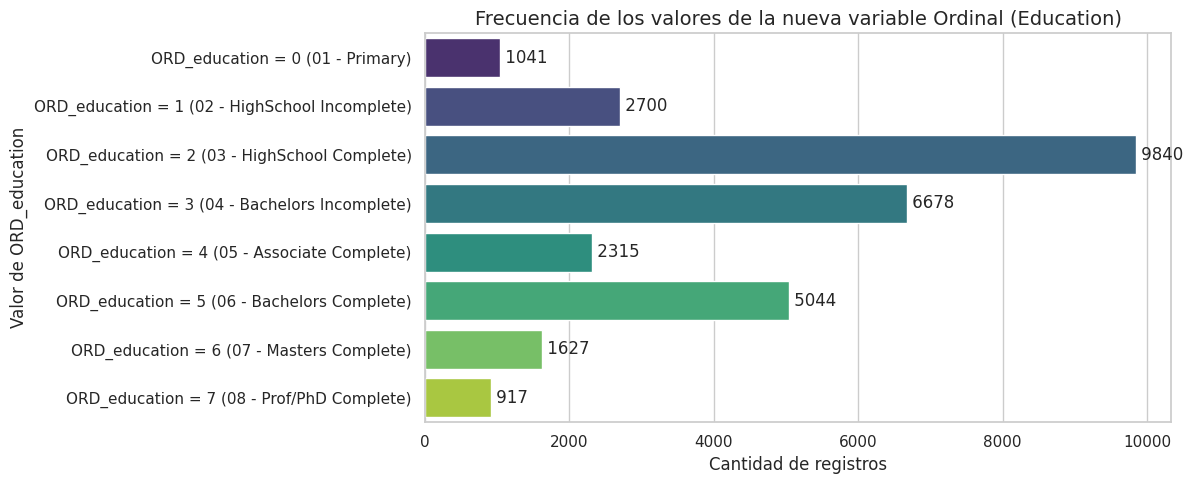

In [16]:
# Plotemaos las transformaciones
plt.figure(figsize=(12, 5))
ord_counts = ORD_education_train.value_counts().sort_index()

# Etiquetas para el eje Y combinando el nombre de la variable, el valor ordinal y su respectivo grupo
y_labels = [f"ORD_education = {i} ({new_order[i]})" for i in ord_counts.index]

sns.barplot(x=ord_counts.values, y=y_labels, hue=y_labels, palette='viridis', legend=False)
plt.title('Frecuencia de los valores de la nueva variable Ordinal (Education)', fontsize=14)
plt.xlabel('Cantidad de registros', fontsize=12)
plt.ylabel('Valor de ORD_education', fontsize=12)

# Agregar anotaciones numéricas
for index, value in enumerate(ord_counts.values):
    plt.text(value, index, f' {int(value)}', va='center')

plt.tight_layout()
plt.show()

- ORD_education

### Marital-status
Estado civil del individuo.

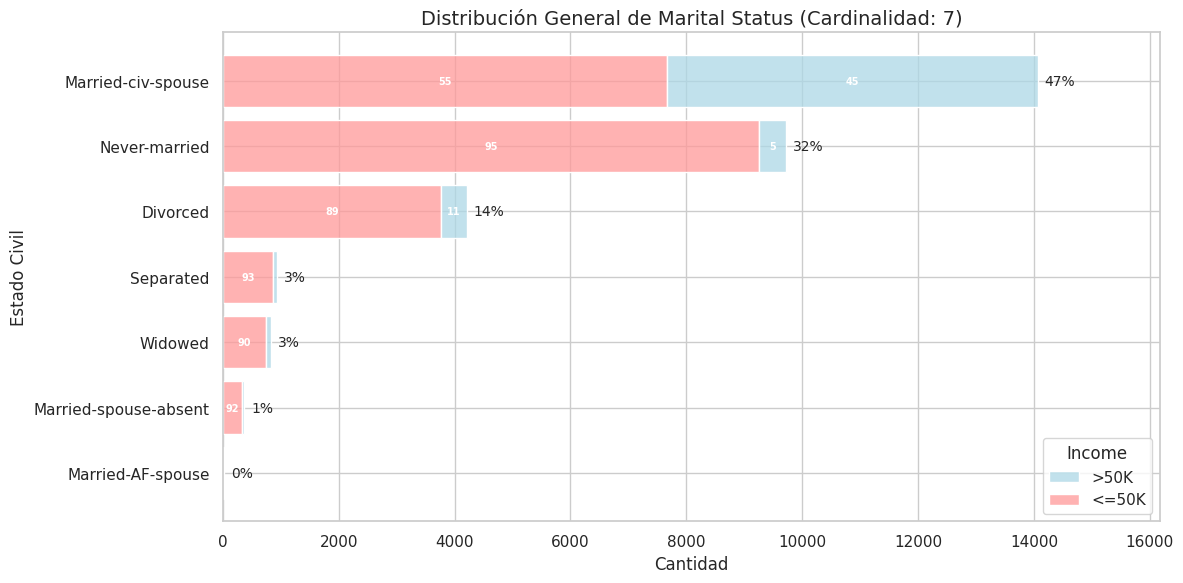

In [17]:
cardinalidad_marital = train['marital-status'].nunique()
conteo_marital = train['marital-status'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos temporalmente para el gráfico
train['marital-status'] = pd.Categorical(train['marital-status'], categories=conteo_marital.index, ordered=True)

sns.histplot(data=train, y='marital-status', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Marital Status (Cardinalidad: {cardinalidad_marital})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Estado Civil', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_marital.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_marital):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra) con el umbral del 2%
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_marital.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['marital-status'] = train['marital-status'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 7 sin orden jerarquico. Usaremos One-Hot Encodding y probaremos con Embeddings luego
- Permite capturar de forma independiente el fuerte impacto que tiene el estado 'Married-civ-spouse' en la variable target (billetera mata galan)
- Que hacemos con Married-AF-spouse???

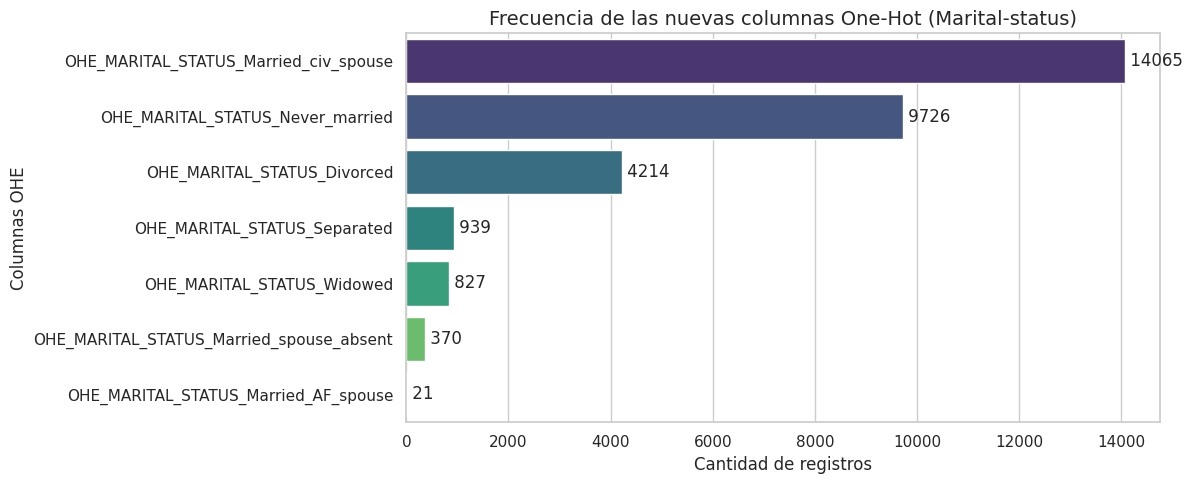

In [18]:
# 5. Transformación Marital-status -> OHE_marital_status
ohe_marital = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos y transformamos
marital_ohe_train_raw = ohe_marital.fit_transform(train[['marital-status']])
marital_ohe_test_raw = ohe_marital.transform(test[['marital-status']])

# Nombres limpios: reemplazamos espacios y guiones por guiones bajos
categories_marital = [cat.replace(' ', '_').replace('-', '_') for cat in ohe_marital.categories_[0]]
columns_ohe_marital = [f"OHE_MARITAL_STATUS_{cat}" for cat in categories_marital]

# DataFrames
OHE_marital_status_train = pd.DataFrame(marital_ohe_train_raw, columns=columns_ohe_marital, index=train.index)
OHE_marital_status_test = pd.DataFrame(marital_ohe_test_raw, columns=columns_ohe_marital, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_marital_status_train)
variables_transformadas_test.append(OHE_marital_status_test)

# Plotemaos las transformaciones
plt.figure(figsize=(12, 5))
ohe_marital_counts = OHE_marital_status_train.sum().sort_values(ascending=False)
sns.barplot(x=ohe_marital_counts.values, y=ohe_marital_counts.index, hue=ohe_marital_counts.index, palette='viridis', legend=False)
plt.title('Frecuencia de las nuevas columnas One-Hot (Marital-status)', fontsize=14)
plt.xlabel('Cantidad de registros', fontsize=12)
plt.ylabel('Columnas OHE', fontsize=12)

# Agregar anotaciones numéricas
for index, value in enumerate(ohe_marital_counts.values):
    plt.text(value, index, f' {int(value)}', va='center')

plt.tight_layout()
plt.show()


- OHE_MARITAL_STATUS_xxx


### Occupation
Tipo de ocupación o área laboral.

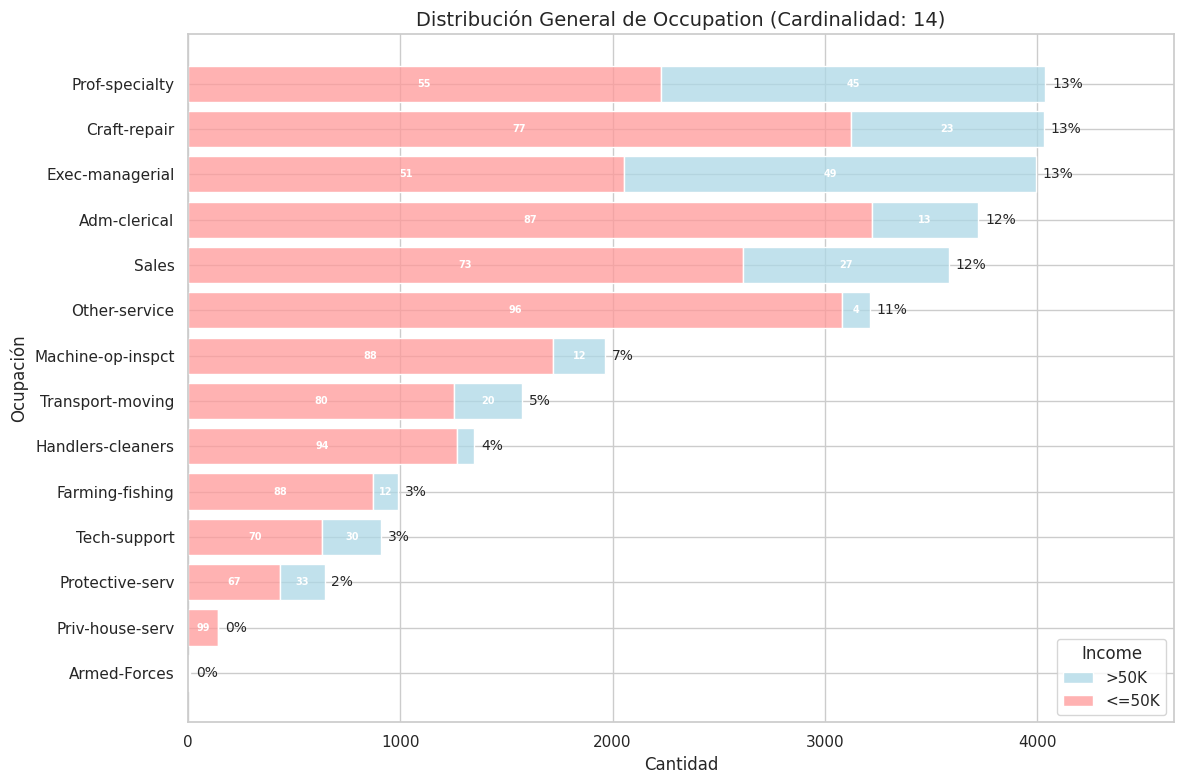

In [19]:
cardinalidad_occupation = train['occupation'].nunique()
conteo_occupation = train['occupation'].value_counts()

fig, ax = plt.subplots(figsize=(12, 8))
# Ordenamos temporalmente para el gráfico
train['occupation'] = pd.Categorical(train['occupation'], categories=conteo_occupation.index, ordered=True)

sns.histplot(data=train, y='occupation', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Occupation (Cardinalidad: {cardinalidad_occupation})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Ocupación', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_occupation.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_occupation):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra) con el umbral del 2%
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_occupation.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['occupation'] = train['occupation'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 14, utilizaremos Embeddings

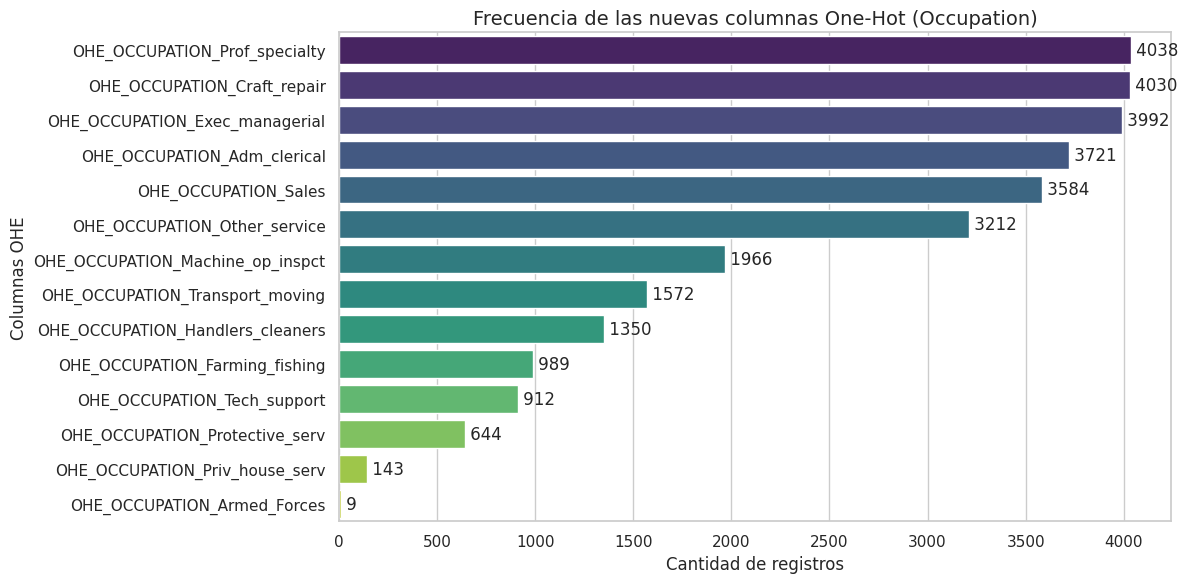

In [20]:
# Transformación Occupation -> OHE_occupation (preparada para el punto C)
ohe_occ = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos y transformamos
occ_ohe_train_raw = ohe_occ.fit_transform(train[['occupation']])
occ_ohe_test_raw = ohe_occ.transform(test[['occupation']])

# Nombres limpios: reemplazamos espacios y guiones por guiones bajos
categories_occ = [cat.replace(' ', '_').replace('-', '_') for cat in ohe_occ.categories_[0]]
columns_ohe_occ = [f"OHE_OCCUPATION_{cat}" for cat in categories_occ]

# DataFrames
OHE_occupation_train = pd.DataFrame(occ_ohe_train_raw, columns=columns_ohe_occ, index=train.index)
OHE_occupation_test = pd.DataFrame(occ_ohe_test_raw, columns=columns_ohe_occ, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_occupation_train)
variables_transformadas_test.append(OHE_occupation_test)

# Ploteamos las transformaciones
plt.figure(figsize=(12, 6))
ohe_occ_counts = OHE_occupation_train.sum().sort_values(ascending=False)
sns.barplot(x=ohe_occ_counts.values, y=ohe_occ_counts.index, hue=ohe_occ_counts.index, palette='viridis', legend=False)
plt.title('Frecuencia de las nuevas columnas One-Hot (Occupation)', fontsize=14)
plt.xlabel('Cantidad de registros', fontsize=12)
plt.ylabel('Columnas OHE', fontsize=12)

# Agregar anotaciones numéricas
for index, value in enumerate(ohe_occ_counts.values):
    plt.text(value, index, f' {int(value)}', va='center')

plt.tight_layout()
plt.show()

- OHE_OCCUPATION_xxx lista para el punto C

### Relationship


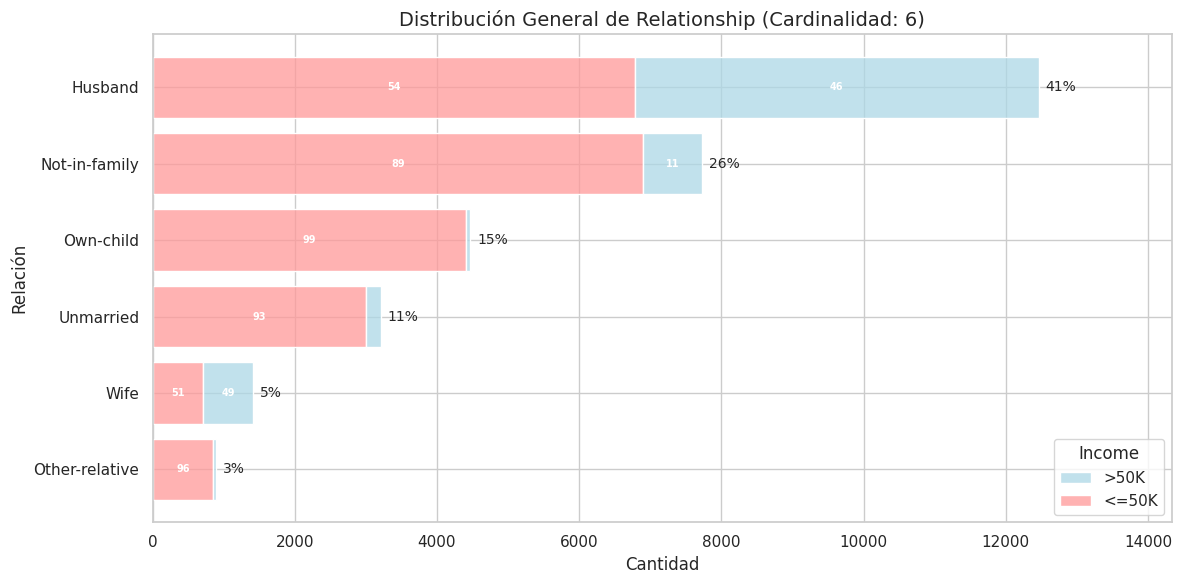

In [21]:
cardinalidad_rel = train['relationship'].nunique()
conteo_rel = train['relationship'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos para el gráfico
train['relationship'] = pd.Categorical(train['relationship'], categories=conteo_rel.index, ordered=True)

sns.histplot(data=train, y='relationship', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Relationship (Cardinalidad: {cardinalidad_rel})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Relación', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_rel.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_rel):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.set_yticks(range(len(conteo_rel)))
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_rel.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['relationship'] = train['relationship'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 6. Utilizaremos One-Hot Encoding ya que son pocas categorías
- Seguramente tenga alta correlacion con Marital_Status

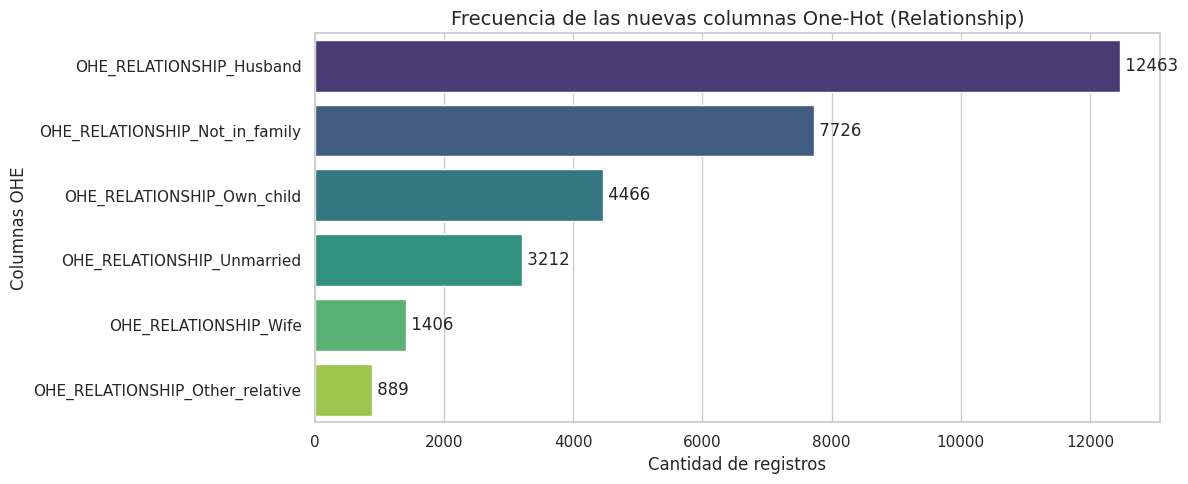

In [22]:
# 1. Transformación Relationship -> OHE_relationship
ohe_rel = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos y transformamos
rel_ohe_train_raw = ohe_rel.fit_transform(train[['relationship']])
rel_ohe_test_raw = ohe_rel.transform(test[['relationship']])

# Nombres limpios: reemplazamos espacios y guiones por guiones bajos
categories_rel = [cat.replace(' ', '_').replace('-', '_') for cat in ohe_rel.categories_[0]]
columns_ohe_rel = [f"OHE_RELATIONSHIP_{cat}" for cat in categories_rel]

# DataFrames
OHE_relationship_train = pd.DataFrame(rel_ohe_train_raw, columns=columns_ohe_rel, index=train.index)
OHE_relationship_test = pd.DataFrame(rel_ohe_test_raw, columns=columns_ohe_rel, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_relationship_train)
variables_transformadas_test.append(OHE_relationship_test)

# Ploteamos las transformaciones
plt.figure(figsize=(12, 5))
ohe_rel_counts = OHE_relationship_train.sum().sort_values(ascending=False)
sns.barplot(x=ohe_rel_counts.values, y=ohe_rel_counts.index, hue=ohe_rel_counts.index, palette='viridis', legend=False)
plt.title('Frecuencia de las nuevas columnas One-Hot (Relationship)', fontsize=14)
plt.xlabel('Cantidad de registros', fontsize=12)
plt.ylabel('Columnas OHE', fontsize=12)

# Agregar anotaciones numéricas
for index, value in enumerate(ohe_rel_counts.values):
    plt.text(value, index, f' {int(value)}', va='center')

plt.tight_layout()
plt.show()


- OHE_RELATIONSHIP_xxx

### Race
Autoidentificación racial del individuo.

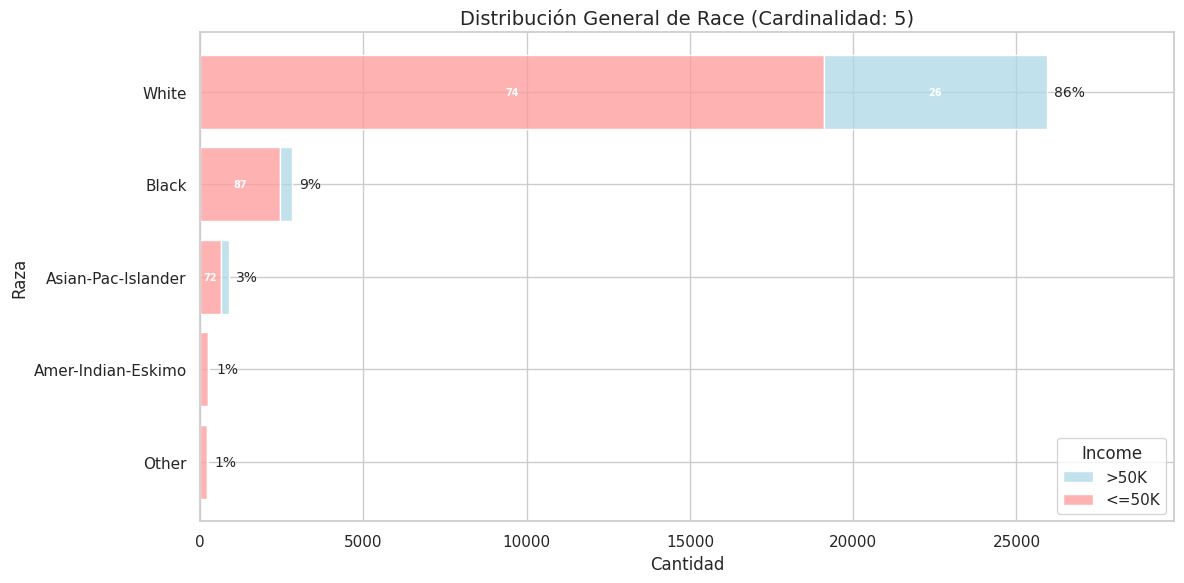

In [23]:
cardinalidad_race = train['race'].nunique()
conteo_race = train['race'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos para el gráfico
train['race'] = pd.Categorical(train['race'], categories=conteo_race.index, ordered=True)

sns.histplot(data=train, y='race', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Race (Cardinalidad: {cardinalidad_race})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Raza', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_race.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_race):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_race):
            total_bar = conteo_race.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['race'] = train['race'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 5
- Ya que son pocos casos que no sean White y Black, agrupamos el resto en Others
- Se ve claramente como los blancos tienen mayores salarios

In [24]:
# 1. Definimos las categorías principales y agrupamos las demás en 'Other'
main_races = ['White', 'Black']

train['race_grouped'] = train['race'].apply(lambda x: x if x in main_races else 'Other')
test['race_grouped'] = test['race'].apply(lambda x: x if x in main_races else 'Other')

# 2. Aplicamos One-Hot Encoding a las categorías agrupadas
ohe_race = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

race_ohe_train_raw = ohe_race.fit_transform(train[['race_grouped']])
race_ohe_test_raw = ohe_race.transform(test[['race_grouped']])

# Nombres de columnas limpios (prefijo en mayúsculas)
columns_ohe_race = [f"OHE_RACE_{cat.replace(' ', '_').replace('-', '_')}" for cat in ohe_race.categories_[0]]

# Crear DataFrames
OHE_race_train = pd.DataFrame(race_ohe_train_raw, columns=columns_ohe_race, index=train.index)
OHE_race_test = pd.DataFrame(race_ohe_test_raw, columns=columns_ohe_race, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_race_train)
variables_transformadas_test.append(OHE_race_test)


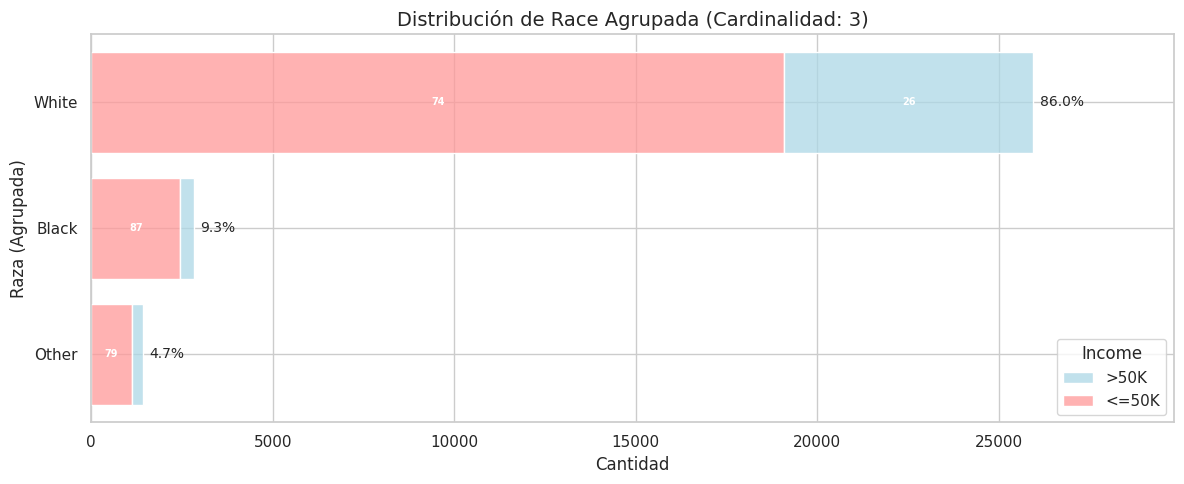

In [25]:
# --- Visualización ---
cardinalidad_race_grouped = train['race_grouped'].nunique()
conteo_race_grouped = train['race_grouped'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['race_grouped'] = pd.Categorical(train['race_grouped'], categories=conteo_race_grouped.index, ordered=True)

sns.histplot(data=train, y='race_grouped', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución de Race Agrupada (Cardinalidad: {cardinalidad_race_grouped})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Raza (Agrupada)', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_race_grouped.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_race_grouped):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_race_grouped):
            total_bar = conteo_race_grouped.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['race_grouped'] = train['race_grouped'].astype(object)
plt.tight_layout()
plt.show()


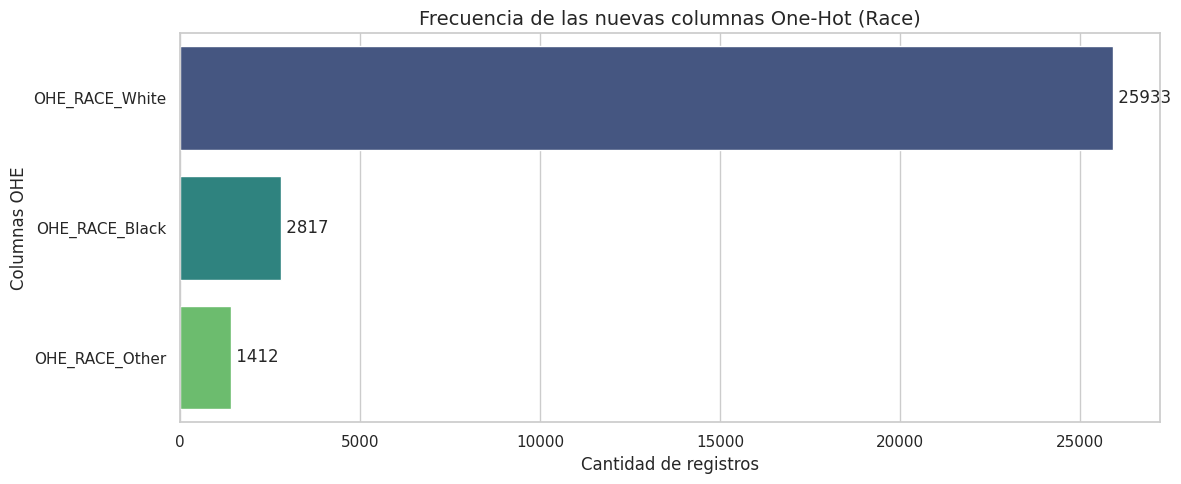

In [26]:
# Ploteamos las transformaciones
plt.figure(figsize=(12, 5))
ohe_race_counts = OHE_race_train.sum().sort_values(ascending=False)
sns.barplot(x=ohe_race_counts.values, y=ohe_race_counts.index, hue=ohe_race_counts.index, palette='viridis', legend=False)
plt.title('Frecuencia de las nuevas columnas One-Hot (Race)', fontsize=14)
plt.xlabel('Cantidad de registros', fontsize=12)
plt.ylabel('Columnas OHE', fontsize=12)

# Agregar anotaciones numéricas
for index, value in enumerate(ohe_race_counts.values):
    plt.text(value, index, f' {int(value)}', va='center')

plt.tight_layout()
plt.show()

- OHE_RACE_xxx

### Sex
Sexo biológico del individuo (masculino o femenino).

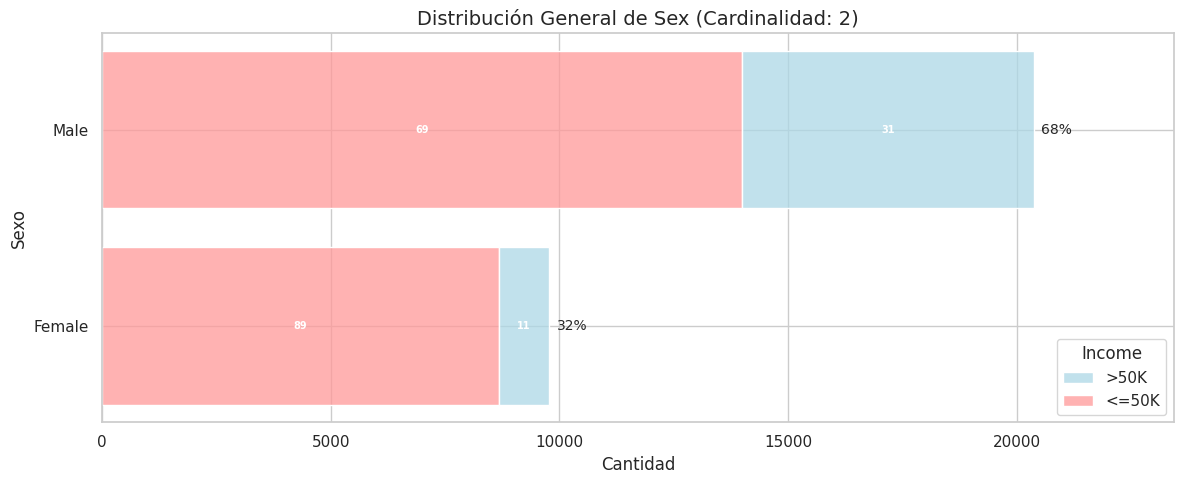

In [27]:
cardinalidad_sex = train['sex'].nunique()
conteo_sex = train['sex'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['sex'] = pd.Categorical(train['sex'], categories=conteo_sex.index, ordered=True)

sns.histplot(data=train, y='sex', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Sex (Cardinalidad: {cardinalidad_sex})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Sexo', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_sex.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_sex):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))  # Corregido: se asegura de que idx sea entero
        if idx < len(conteo_sex):
            total_bar = conteo_sex.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['sex'] = train['sex'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 2 (Binaria)
- 2/3 de la base son hombres
- La proporcionde hombres con salarios altos es casi del triple que de mujeres

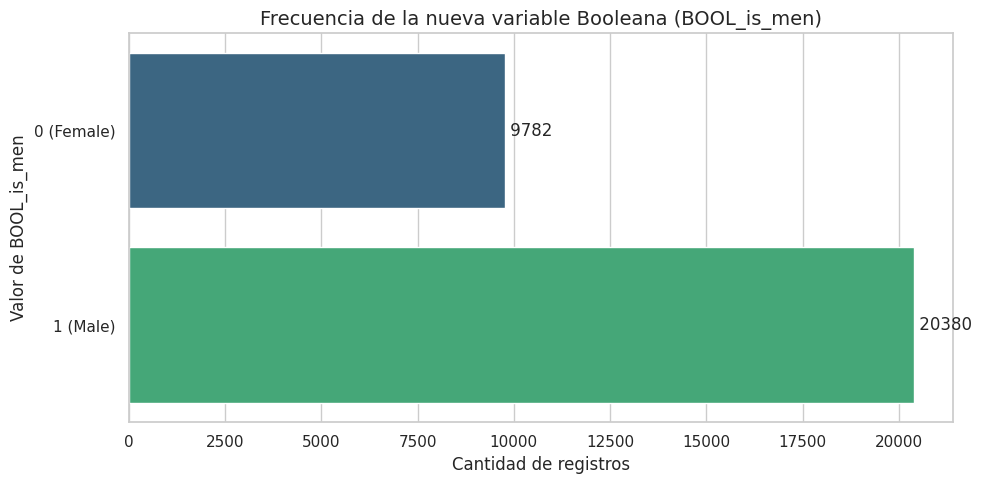

In [28]:
# 8. Transformación Sex -> BOOL_is_men
sex_mapping = {'Male': 1, 'Female': 0}

BOOL_is_men_train = train['sex'].map(sex_mapping).astype(int)
BOOL_is_men_test = test['sex'].map(sex_mapping).astype(int)

# Asignamos nombre para consistencia
BOOL_is_men_train.name = 'BOOL_is_men'
BOOL_is_men_test.name = 'BOOL_is_men'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(BOOL_is_men_train)
variables_transformadas_test.append(BOOL_is_men_test)

# Ploteamos las transformaciones
plt.figure(figsize=(10, 5))
sex_counts = BOOL_is_men_train.value_counts().sort_index()
labels = ['0 (Female)', '1 (Male)']

sns.barplot(x=sex_counts.values, y=labels, hue=labels, palette='viridis', legend=False)
plt.title('Frecuencia de la nueva variable Booleana (BOOL_is_men)', fontsize=14)
plt.xlabel('Cantidad de registros', fontsize=12)
plt.ylabel('Valor de BOOL_is_men', fontsize=12)

# Agregar anotaciones numéricas
for index, value in enumerate(sex_counts.values):
    plt.text(value, index, f' {int(value)}', va='center')

plt.tight_layout()
plt.show()

- BOOL_is_men

### Skill-profile
Habilidad principal o conocimiento técnico adquirido que podría aplicar en el trabajo.

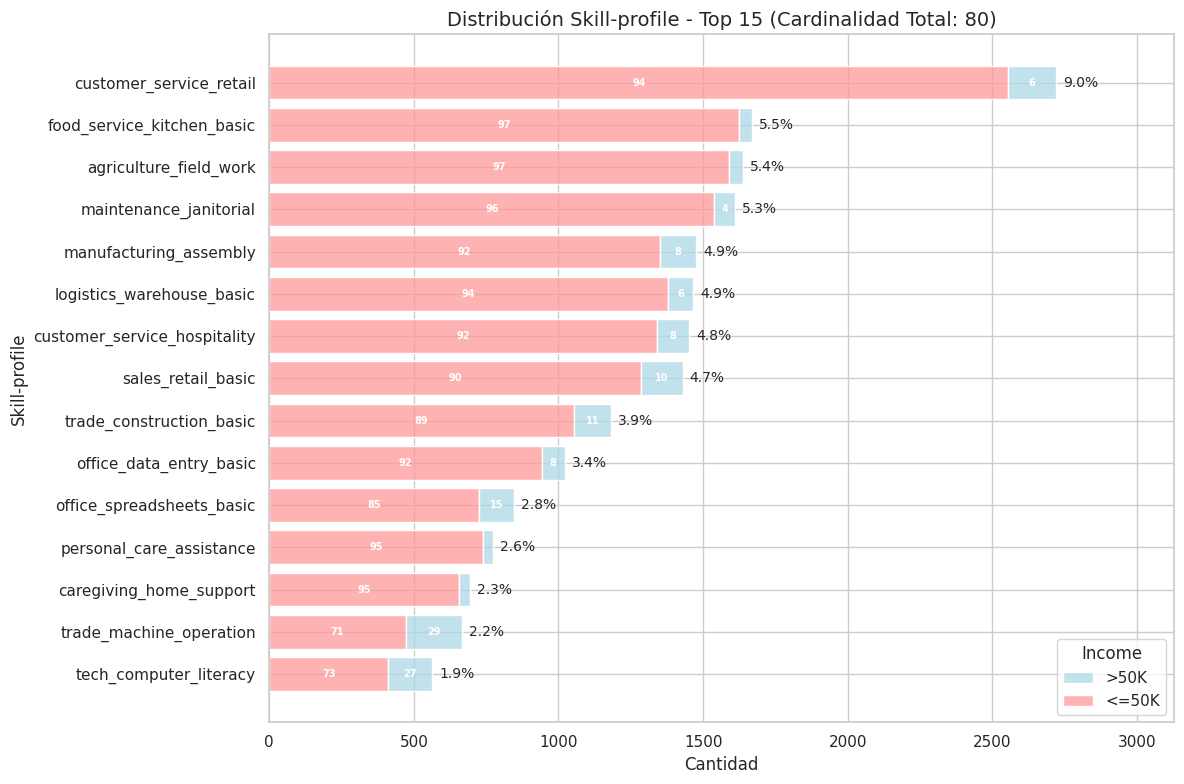

In [29]:
cardinalidad_skill = train['skill-profile'].nunique()
conteo_skill = train['skill-profile'].value_counts()
top_15_skills = conteo_skill.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
train_top = train[train['skill-profile'].isin(top_15_skills.index)].copy()
train_top['skill-profile'] = pd.Categorical(train_top['skill-profile'], categories=top_15_skills.index, ordered=True)

sns.histplot(data=train_top, y='skill-profile', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución Skill-profile - Top 15 (Cardinalidad Total: {cardinalidad_skill})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Skill-profile', fontsize=12)

sns.move_legend(ax, "lower right", title='Income')

ax.set_xlim(0, top_15_skills.max() * 1.15)
total_len = len(train)
for i, width in enumerate(top_15_skills):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(top_15_skills):
            total_bar = top_15_skills.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

- Cardinalidad de 80, Embeddings

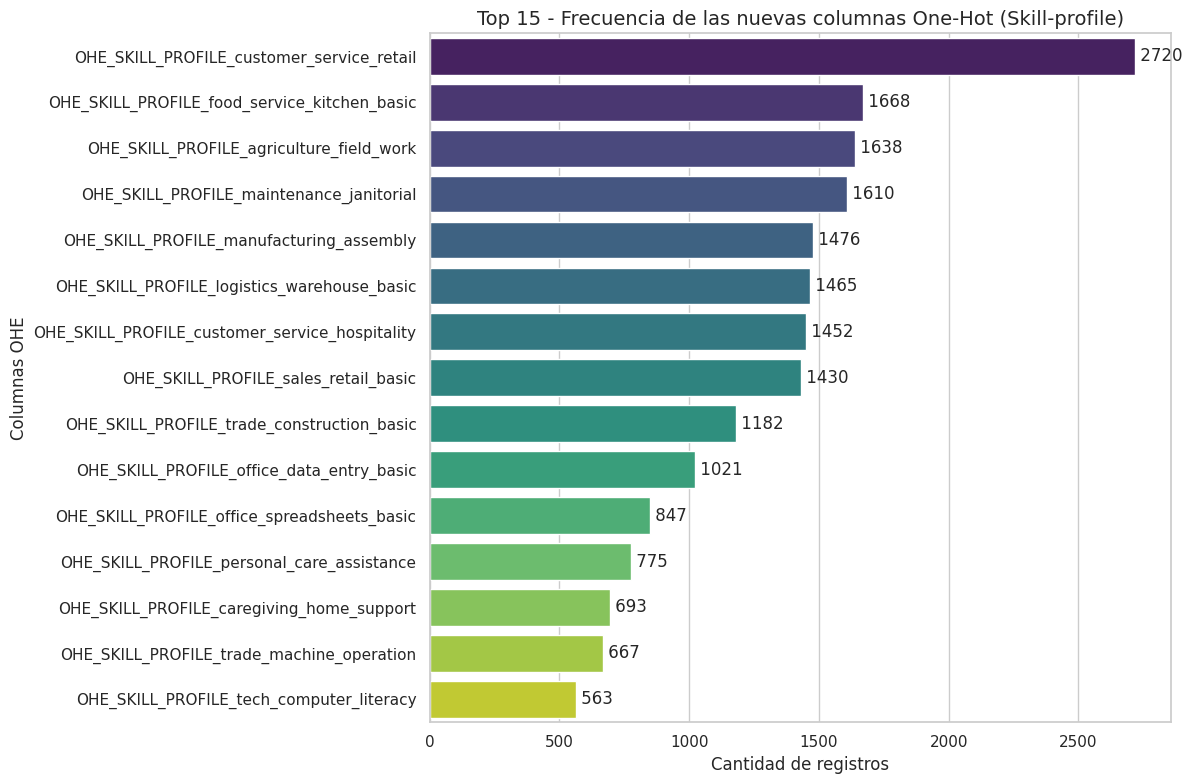

In [30]:
# Transformación Skill-profile -> OHE_skill_profile
ohe_skill = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos y transformamos
skill_ohe_train_raw = ohe_skill.fit_transform(train[['skill-profile']])
skill_ohe_test_raw = ohe_skill.transform(test[['skill-profile']])

# Nombres limpios: reemplazamos espacios y guiones por guiones bajos
categories_skill = [cat.replace(' ', '_').replace('-', '_') for cat in ohe_skill.categories_[0]]
columns_ohe_skill = [f"OHE_SKILL_PROFILE_{cat}" for cat in categories_skill]

# DataFrames
OHE_skill_profile_train = pd.DataFrame(skill_ohe_train_raw, columns=columns_ohe_skill, index=train.index)
OHE_skill_profile_test = pd.DataFrame(skill_ohe_test_raw, columns=columns_ohe_skill, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_skill_profile_train)
variables_transformadas_test.append(OHE_skill_profile_test)

# Ploteamos el top 15 de las transformaciones
plt.figure(figsize=(12, 8))
ohe_skill_counts = OHE_skill_profile_train.sum().sort_values(ascending=False).head(15)
sns.barplot(x=ohe_skill_counts.values, y=ohe_skill_counts.index, hue=ohe_skill_counts.index, palette='viridis', legend=False)
plt.title('Top 15 - Frecuencia de las nuevas columnas One-Hot (Skill-profile)', fontsize=14)
plt.xlabel('Cantidad de registros', fontsize=12)
plt.ylabel('Columnas OHE', fontsize=12)

# Agregar anotaciones numéricas
for index, value in enumerate(ohe_skill_counts.values):
    plt.text(value, index, f' {int(value)}', va='center')

plt.tight_layout()
plt.show()

- OHE_SKILL_PROFILE_xx lista para el punto C

### Native-country
País de nacimiento del individuo.

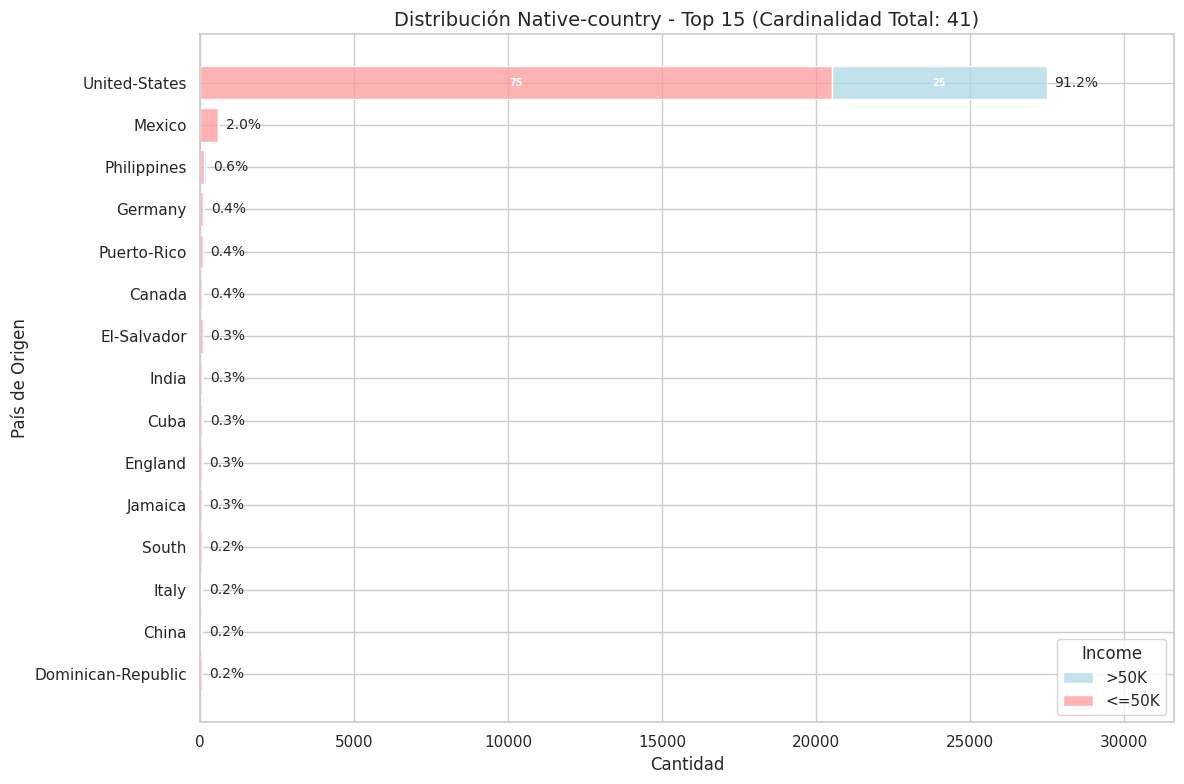

In [31]:
cardinalidad_country = train['native-country'].nunique()
conteo_country = train['native-country'].value_counts()
top_15_countries = conteo_country.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
train_top_c = train[train['native-country'].isin(top_15_countries.index)].copy()
train_top_c['native-country'] = pd.Categorical(train_top_c['native-country'], categories=top_15_countries.index, ordered=True)

sns.histplot(data=train_top_c, y='native-country', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución Native-country - Top 15 (Cardinalidad Total: {cardinalidad_country})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('País de Origen', fontsize=12)

sns.move_legend(ax, "lower right", title='Income')

ax.set_xlim(0, top_15_countries.max() * 1.15)
total_len = len(train)
for i, width in enumerate(top_15_countries):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(top_15_countries):
            total_bar = top_15_countries.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

- Cardinalidad de 41, pero pocos registors con valores distintos de US y MEX. Reagrupamos y One-Hot

In [32]:
# Agrupamos en United-States, Mexico y Other, luego aplicamos One-Hot Encoding

main_countries = ['United-States', 'Mexico']

train['country_grouped'] = train['native-country'].str.strip().apply(lambda x: x if x in main_countries else 'Other')
test['country_grouped'] = test['native-country'].str.strip().apply(lambda x: x if x in main_countries else 'Other')

ohe_country = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
country_ohe_train_raw = ohe_country.fit_transform(train[['country_grouped']])
country_ohe_test_raw = ohe_country.transform(test[['country_grouped']])

columns_ohe_country = [f"OHE_COUNTRY_{cat.replace('-', '_')}" for cat in ohe_country.categories_[0]]

OHE_country_train = pd.DataFrame(country_ohe_train_raw, columns=columns_ohe_country, index=train.index)
OHE_country_test = pd.DataFrame(country_ohe_test_raw, columns=columns_ohe_country, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_country_train)
variables_transformadas_test.append(OHE_country_test)


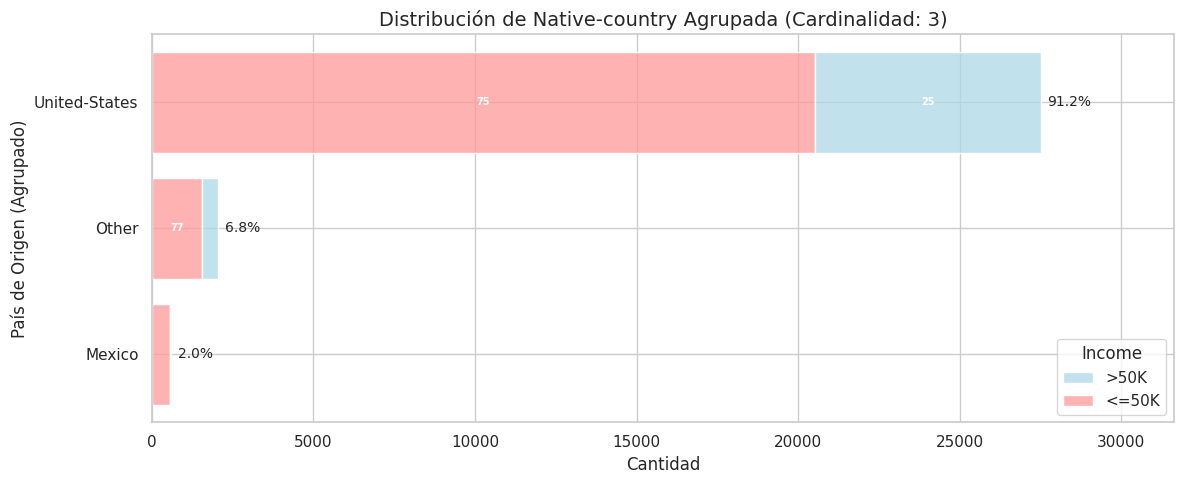

In [33]:
# --- Visualización ---
cardinalidad_country_grouped = train['country_grouped'].nunique()
conteo_country_grouped = train['country_grouped'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['country_grouped'] = pd.Categorical(train['country_grouped'], categories=conteo_country_grouped.index, ordered=True)

sns.histplot(data=train, y='country_grouped', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución de Native-country Agrupada (Cardinalidad: {cardinalidad_country_grouped})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('País de Origen (Agrupado)', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_country_grouped.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_country_grouped):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_country_grouped):
            total_bar = conteo_country_grouped.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['country_grouped'] = train['country_grouped'].astype(object)
plt.tight_layout()
plt.show()

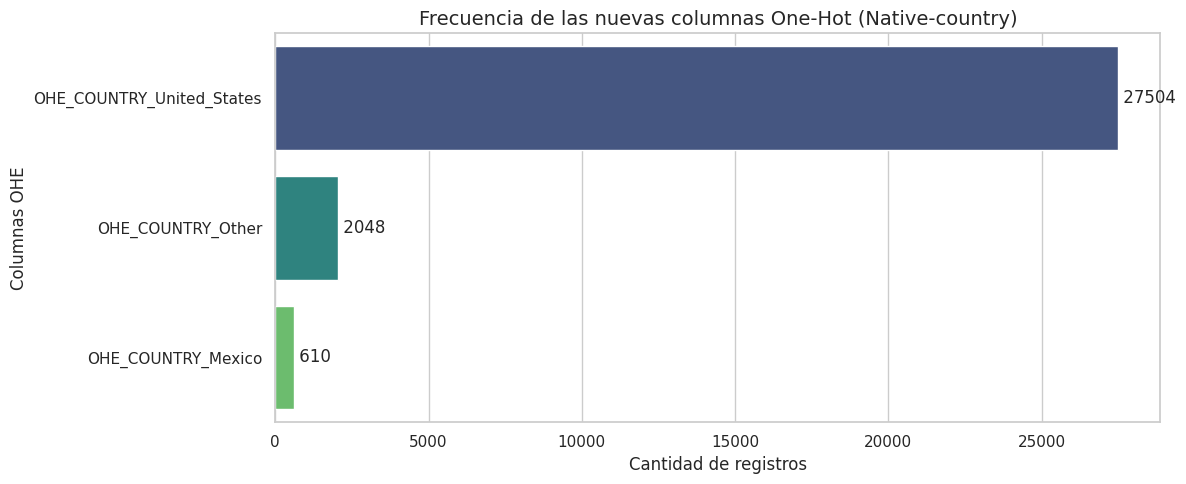

In [34]:
# Ploteamos las transformaciones
plt.figure(figsize=(12, 5))
ohe_country_counts = OHE_country_train.sum().sort_values(ascending=False)
sns.barplot(x=ohe_country_counts.values, y=ohe_country_counts.index, hue=ohe_country_counts.index, palette='viridis', legend=False)
plt.title('Frecuencia de las nuevas columnas One-Hot (Native-country)', fontsize=14)
plt.xlabel('Cantidad de registros', fontsize=12)
plt.ylabel('Columnas OHE', fontsize=12)

# Agregar anotaciones numéricas
for index, value in enumerate(ohe_country_counts.values):
    plt.text(value, index, f' {int(value)}', va='center')

plt.tight_layout()
plt.show()

- OHE_COUNTRY_xxx

### Hours-per-week
Cantidad de horas trabajadas por semana (variable numérica).

Estadísticas descriptivas de la variable 'hours-per-week':


,hours-per-week
count,30162.000000
mean,40.931238
std,11.979984
min,1.000000
25%,40.000000
50%,40.000000
75%,45.000000
max,99.000000


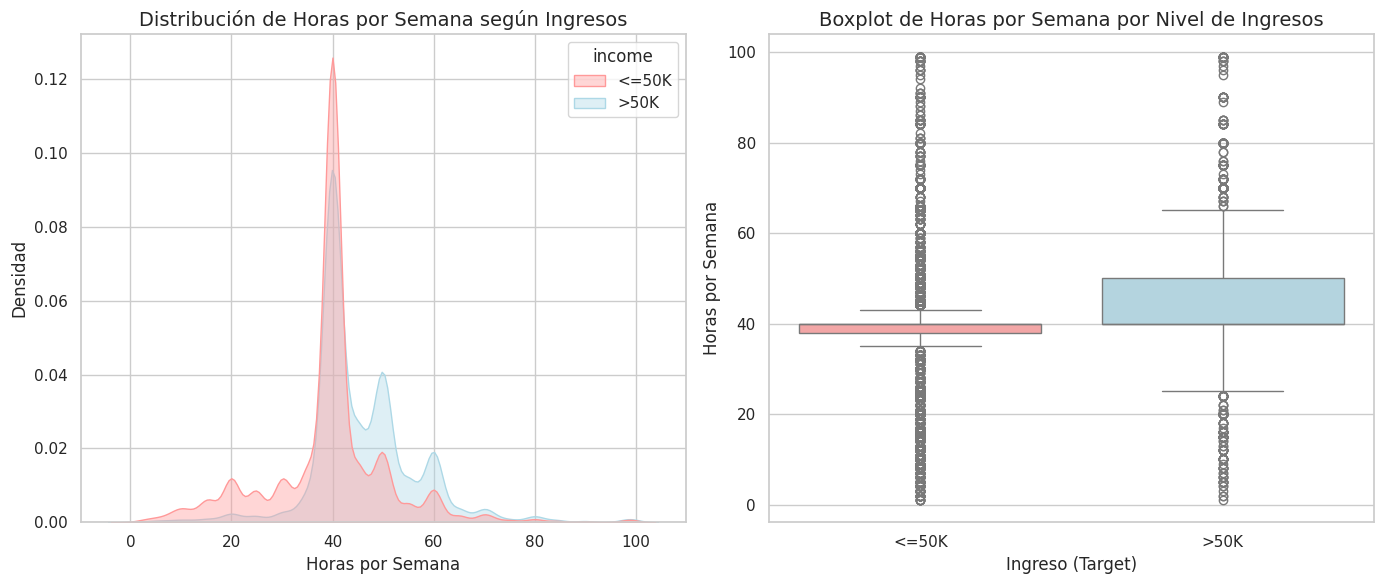

In [35]:
# Mostrar estadísticas descriptivas de la variable 'hours-per-week'
print("Estadísticas descriptivas de la variable 'hours-per-week':")
display(train['hours-per-week'].describe())

# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico KDE superpuesto por clase (Income)
sns.kdeplot(
    data=train, x='hours-per-week', hue='income',
    hue_order=['<=50K', '>50K'],
    ax=axes[0],
    palette=custom_palette,
    fill=True,
    alpha=0.4,
    common_norm=False
)
axes[0].set_title('Distribución de Horas por Semana según Ingresos', fontsize=14)
axes[0].set_xlabel('Horas por Semana', fontsize=12)
axes[0].set_ylabel('Densidad', fontsize=12)

# 2. Boxplot de Horas por Semana por clase (Income)
sns.boxplot(data=train, x='income', y='hours-per-week', hue='income', ax=axes[1], palette=custom_palette, legend=False)
axes[1].set_title('Boxplot de Horas por Semana por Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Ingreso (Target)', fontsize=12)
axes[1].set_ylabel('Horas por Semana', fontsize=12)

plt.tight_layout()
plt.show()

- Variable continua de baja dispersion
- La distribucion se centra en 40hs (la gente que trabja full time)
- La binerizamos y trabajamos como Ordinal, o la capeamos y trabajamos como continua

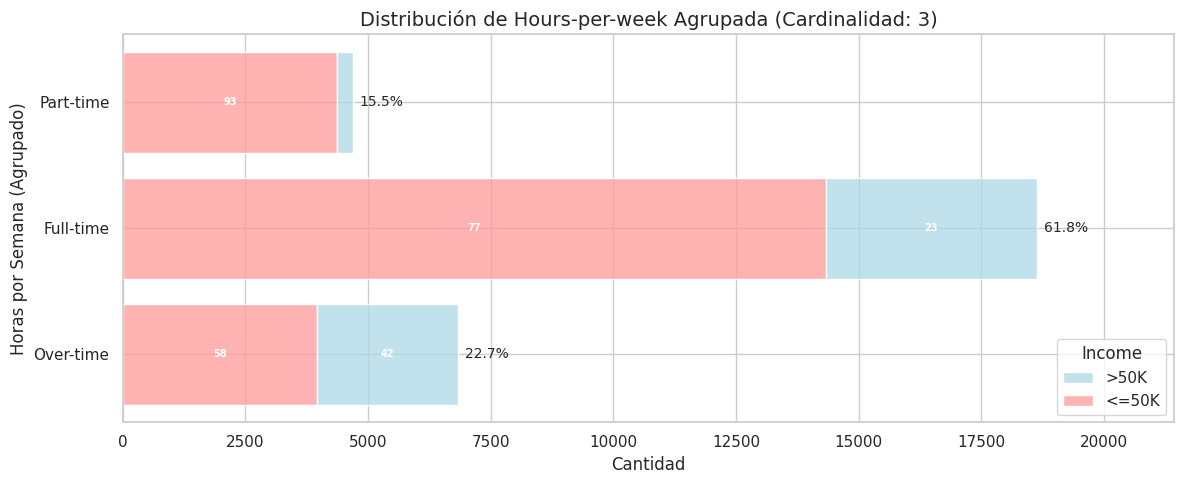

In [36]:
# 9. Transformación Hours-per-week -> Binning manual

# Definimos los rangos: Part-time (<35), Full-time (35-45), Over-time (>45)
def bin_hours(h):
    if h < 35:
        return 'Part-time'
    elif 35 <= h <= 45:
        return 'Full-time'

    else:
        return 'Over-time'

train['hours_binned'] = train['hours-per-week'].apply(bin_hours)
test['hours_binned'] = test['hours-per-week'].apply(bin_hours)

# --- Visualización ---
cardinalidad_hours_binned = train['hours_binned'].nunique()
order_hours = ['Part-time', 'Full-time', 'Over-time']
conteo_hours_binned = train['hours_binned'].value_counts().reindex(order_hours)

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['hours_binned'] = pd.Categorical(train['hours_binned'], categories=order_hours, ordered=True)

sns.histplot(data=train, y='hours_binned', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución de Hours-per-week Agrupada (Cardinalidad: {cardinalidad_hours_binned})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Horas por Semana (Agrupado)', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_hours_binned.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_hours_binned):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_hours_binned):
            total_bar = conteo_hours_binned.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['hours_binned'] = train['hours_binned'].astype(object)
plt.tight_layout()
plt.show()


- Como era de esperar, se verificacomo la gente que trabaja mas horas tiene mejores salarios a nivel nominal

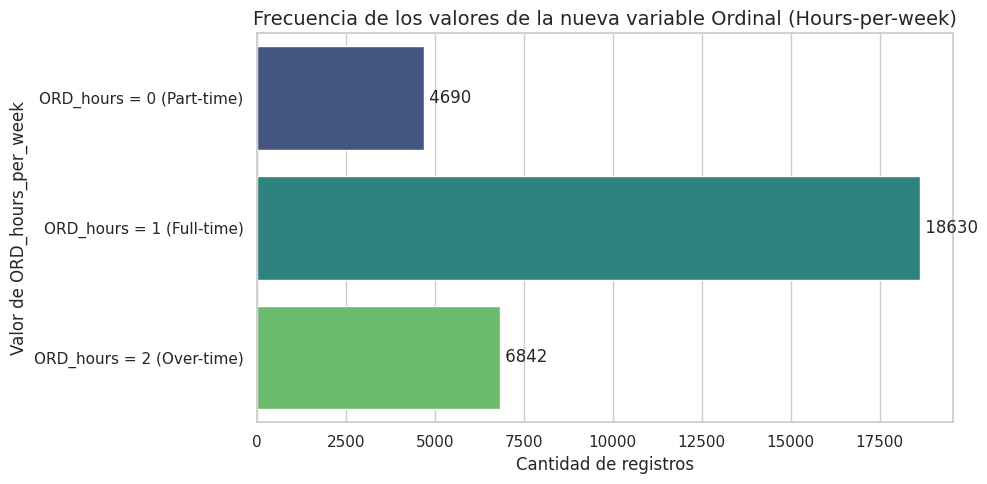

In [37]:
# Aplicamos Ordinal Encoding manteniendo el orden lógico

# Definimos el orden explícito: Part-time (0) < Full-time (1) < Over-time (2)
hours_categories = [['Part-time', 'Full-time', 'Over-time']]
encoder_hours = OrdinalEncoder(categories=hours_categories)

ORD_hours_train = pd.Series(
    encoder_hours.fit_transform(train[['hours_binned']]).flatten(),
    index=train.index,
    name='ORD_hours_per_week'
)

ORD_hours_test = pd.Series(
    encoder_hours.transform(test[['hours_binned']]).flatten(),
    index=test.index,
    name='ORD_hours_per_week'
)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(ORD_hours_train)
variables_transformadas_test.append(ORD_hours_test)

# Ploteamos la transformacion
plt.figure(figsize=(10, 5))
ord_hours_counts = ORD_hours_train.value_counts().sort_index()

# Etiquetas para el eje Y
y_labels_hours = [f"ORD_hours = {int(i)} ({order_hours[int(i)]})" for i in ord_hours_counts.index]

sns.barplot(x=ord_hours_counts.values, y=y_labels_hours, hue=y_labels_hours, palette='viridis', legend=False)
plt.title('Frecuencia de los valores de la nueva variable Ordinal (Hours-per-week)', fontsize=14)
plt.xlabel('Cantidad de registros', fontsize=12)
plt.ylabel('Valor de ORD_hours_per_week', fontsize=12)

# Agregar anotaciones numéricas
for index, value in enumerate(ord_hours_counts.values):
    plt.text(value, index, f' {int(value)}', va='center')

plt.tight_layout()
plt.show()

- ORD_hours_per_week

### Capital-gain
Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

,capital-gain
count,30162.000000
mean,1092.007858
std,7406.346497
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000



Cantidad de registros con capital-gain igual a 0: 27624
Porcentaje de registros con capital-gain igual a 0: 91.59%



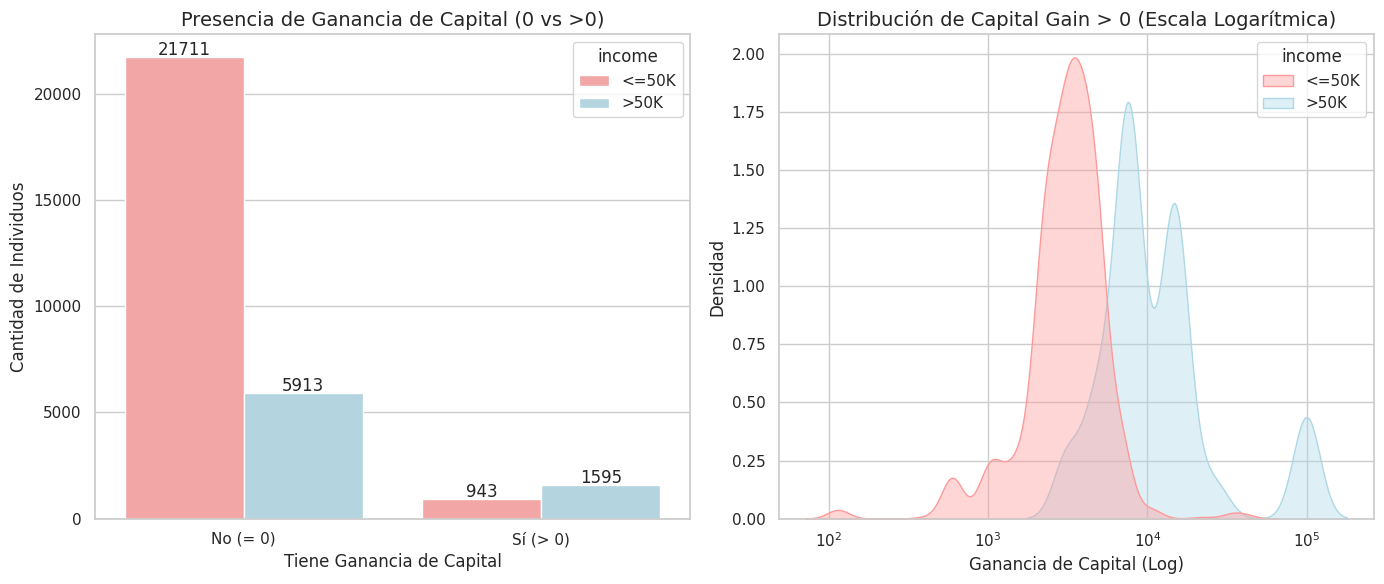

In [38]:
display(train['capital-gain'].describe())

zeros_count = (train['capital-gain'] == 0).sum()
total_count = len(train)
zeros_pct = (zeros_count / total_count) * 100

print(f"\nCantidad de registros con capital-gain igual a 0: {zeros_count}")
print(f"Porcentaje de registros con capital-gain igual a 0: {zeros_pct:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

train['has_capital_gain'] = train['capital-gain'] > 0

# 1. Countplot de Ceros vs No Ceros
sns.countplot(data=train, x='has_capital_gain', hue='income', ax=axes[0], palette=custom_palette)
axes[0].set_title('Presencia de Ganancia de Capital (0 vs >0)', fontsize=14)
axes[0].set_xlabel('Tiene Ganancia de Capital', fontsize=12)
axes[0].set_ylabel('Cantidad de Individuos', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No (= 0)', 'Sí (> 0)'])

# Agregar valores exactos sobre las barras del countplot
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Distribución de las ganancias > 0 (Escala Logarítmica)
non_zero_gains = train[train['capital-gain'] > 0]
sns.kdeplot(
    data=non_zero_gains, x='capital-gain', hue='income',
    hue_order=['<=50K', '>50K'],
    ax=axes[1],
    palette=custom_palette,
    fill=True,
    alpha=0.4,
    common_norm=False,
    log_scale=True
)
axes[1].set_title('Distribución de Capital Gain > 0 (Escala Logarítmica)', fontsize=14)
axes[1].set_xlabel('Ganancia de Capital (Log)', fontsize=12)
axes[1].set_ylabel('Densidad', fontsize=12)

plt.tight_layout()
plt.show()

train = train.drop(columns=['has_capital_gain'])

- Variable Continua
- 92% de los registros tienen valor de 0
- Para los que reportan algo de Capital Gain, la proporcion de registros con Ingresos altos se considerablemente mayor contra los que no reportan
- Distribucion muy sezgada hacia la derecha, aplicamos Log Transform y luego Escalamos

In [39]:
# 1. Transformación Logarítmica para manejar el sesgo extremo
log_gain_train = np.log1p(train[['capital-gain']])
log_gain_test = np.log1p(test[['capital-gain']])

# 2. Escalado de la magnitud logarítmica para la red neuronal
scaler_gain = MinMaxScaler()

LOG_capital_gain_train = pd.Series(
    scaler_gain.fit_transform(log_gain_train).flatten(),
    index=train.index,
    name='LOG_capital_gain'
)

LOG_capital_gain_test = pd.Series(
    scaler_gain.transform(log_gain_test).flatten(),
    index=test.index,
    name='LOG_capital_gain'
)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(LOG_capital_gain_train)
variables_transformadas_test.append(LOG_capital_gain_test)

display(LOG_capital_gain_train.describe())

,LOG_capital_gain
count,30162.000000
mean,0.064592
std,0.214586
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


- Creamos LOG_capital_gain que sería la variable original transformada aplicando logaritmo y luego escalada con MinMax Scaler.

### Capital-loss
Pérdidas declaradas por capital.


Cantidad de registros con capital-loss igual a 0: 28735
Porcentaje de registros con capital-loss igual a 0: 95.27%



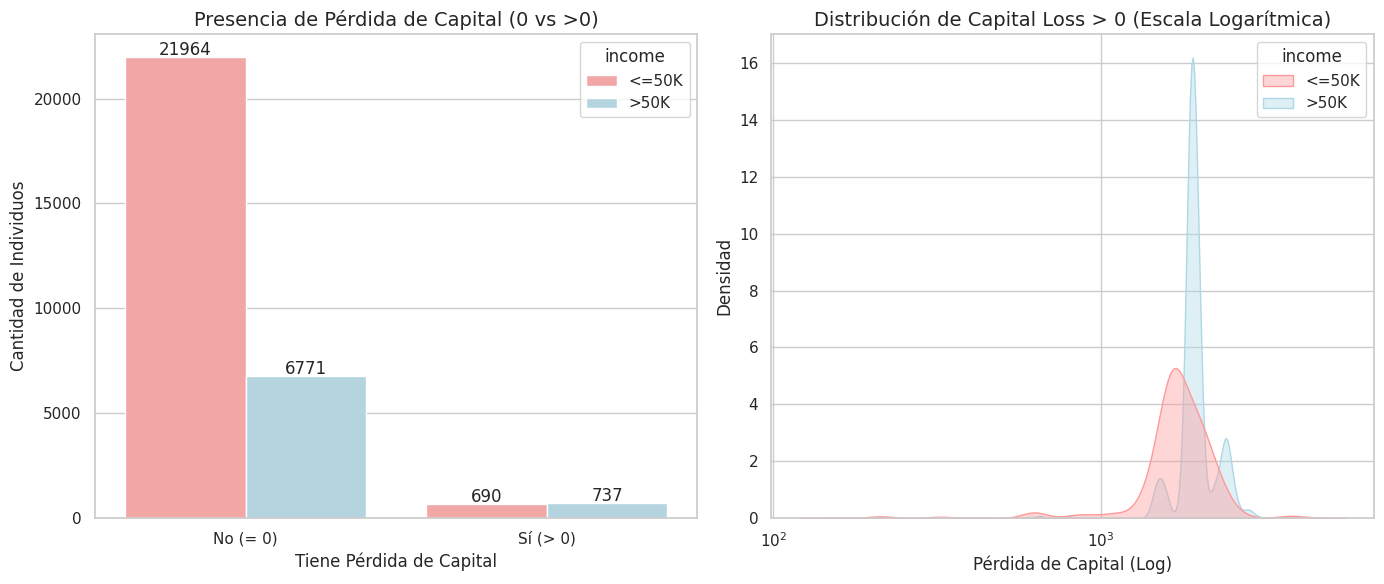

In [40]:
zeros_loss_count = (train['capital-loss'] == 0).sum()
total_count = len(train)
zeros_loss_pct = (zeros_loss_count / total_count) * 100

print(f"\nCantidad de registros con capital-loss igual a 0: {zeros_loss_count}")
print(f"Porcentaje de registros con capital-loss igual a 0: {zeros_loss_pct:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

train['has_capital_loss'] = train['capital-loss'] > 0

# 1. Countplot de Ceros vs No Ceros
sns.countplot(data=train, x='has_capital_loss', hue='income', ax=axes[0], palette=custom_palette)
axes[0].set_title('Presencia de Pérdida de Capital (0 vs >0)', fontsize=14)
axes[0].set_xlabel('Tiene Pérdida de Capital', fontsize=12)
axes[0].set_ylabel('Cantidad de Individuos', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No (= 0)', 'Sí (> 0)'])

# Agregar valores exactos sobre las barras del countplot
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Distribución de las pérdidas > 0 (Escala Logarítmica)
non_zero_losses = train[train['capital-loss'] > 0]
sns.kdeplot(
    data=non_zero_losses, x='capital-loss', hue='income',
    hue_order=['<=50K', '>50K'],
    ax=axes[1],
    palette=custom_palette,
    fill=True,
    alpha=0.4,
    common_norm=False,
    log_scale=True
)
axes[1].set_title('Distribución de Capital Loss > 0 (Escala Logarítmica)', fontsize=14)
axes[1].set_xlabel('Pérdida de Capital (Log)', fontsize=12)
axes[1].set_ylabel('Densidad', fontsize=12)

plt.tight_layout()
plt.show()

train = train.drop(columns=['has_capital_loss'])

- Tambien Continua, con 95% de registros en 0
- Aqui las proporciones de los que tienen Ingresos altos e Ingresos bajos es casi igual, a diferencia como pasaba en Captial-Gain
- Tambien con mucho sezgo hacia la cola derecha, aplicamos Log Transform y leugo MinMax Scaler

In [41]:
# 1. Transformación Logarítmica para manejar el sesgo extremo
log_loss_train = np.log1p(train[['capital-loss']])
log_loss_test = np.log1p(test[['capital-loss']])

# 2. Escalado MinMax de la magnitud logarítmica
scaler_loss = MinMaxScaler()

LOG_capital_loss_train = pd.Series(
    scaler_loss.fit_transform(log_loss_train).flatten(),
    index=train.index,
    name='LOG_capital_loss'
)

LOG_capital_loss_test = pd.Series(
    scaler_loss.transform(log_loss_test).flatten(),
    index=test.index,
    name='LOG_capital_loss'
)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(LOG_capital_loss_train)
variables_transformadas_test.append(LOG_capital_loss_test)

- Creamos LOG_capital_loss que sería la variable original transformada aplicando logaritmo y luego escalada con MinMax Scaler.

### Consolidación Final de Variables


In [42]:
# Creación de los DataFrames finales X_train y X_test concatenando las listas de consolidación
X_train = pd.concat(variables_transformadas_train, axis=1)
X_test = pd.concat(variables_transformadas_test, axis=1)

# Eliminar columnas duplicadas (por si se corrieron celdas de transformación múltiples veces)
X_train = X_train.loc[:, ~X_train.columns.duplicated()].copy()
X_test = X_test.loc[:, ~X_test.columns.duplicated()].copy()

# Asignación de la variable objetivo
y_train = BOOL_Income_train
y_test = BOOL_Income_test

# Verificación de dimensiones y visualización
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Total de features: {X_train.shape[1]}")
display(X_train.head())


Dimensiones de X_train: (30162, 126)
Dimensiones de X_test: (15060, 126)
Total de features: 126


,SCA_age,OHE_WORKCLASS_Federal-gov,OHE_WORKCLASS_Local-gov,OHE_WORKCLASS_Private,OHE_WORKCLASS_Self-emp-inc,OHE_WORKCLASS_Self-emp-not-inc,OHE_WORKCLASS_State-gov,OHE_WORKCLASS_Without-pay,ORD_education,OHE_MARITAL_STATUS_Divorced,OHE_MARITAL_STATUS_Married_AF_spouse,OHE_MARITAL_STATUS_Married_civ_spouse,OHE_MARITAL_STATUS_Married_spouse_absent,OHE_MARITAL_STATUS_Never_married,OHE_MARITAL_STATUS_Separated,OHE_MARITAL_STATUS_Widowed,OHE_OCCUPATION_Adm_clerical,OHE_OCCUPATION_Armed_Forces,OHE_OCCUPATION_Craft_repair,OHE_OCCUPATION_Exec_managerial,OHE_OCCUPATION_Farming_fishing,OHE_OCCUPATION_Handlers_cleaners,OHE_OCCUPATION_Machine_op_inspct,OHE_OCCUPATION_Other_service,OHE_OCCUPATION_Priv_house_serv,OHE_OCCUPATION_Prof_specialty,OHE_OCCUPATION_Protective_serv,OHE_OCCUPATION_Sales,OHE_OCCUPATION_Tech_support,OHE_OCCUPATION_Transport_moving,OHE_RELATIONSHIP_Husband,OHE_RELATIONSHIP_Not_in_family,OHE_RELATIONSHIP_Other_relative,OHE_RELATIONSHIP_Own_child,OHE_RELATIONSHIP_Unmarried,OHE_RELATIONSHIP_Wife,OHE_RACE_Black,OHE_RACE_Other,OHE_RACE_White,BOOL_is_men,OHE_SKILL_PROFILE_accounting_bookkeeping,OHE_SKILL_PROFILE_accounting_payroll,OHE_SKILL_PROFILE_admin_document_control,OHE_SKILL_PROFILE_admin_procurement_support,OHE_SKILL_PROFILE_agriculture_field_work,OHE_SKILL_PROFILE_automotive_repair,OHE_SKILL_PROFILE_business_reporting_basic,OHE_SKILL_PROFILE_caregiving_home_support,OHE_SKILL_PROFILE_community_program_coordination,OHE_SKILL_PROFILE_consulting_process_improvement,OHE_SKILL_PROFILE_customer_service_hospitality,OHE_SKILL_PROFILE_customer_service_retail,OHE_SKILL_PROFILE_customer_success_operations,OHE_SKILL_PROFILE_delivery_local_routes,OHE_SKILL_PROFILE_education_classroom_teaching,OHE_SKILL_PROFILE_education_curriculum_design,OHE_SKILL_PROFILE_education_research_methods,OHE_SKILL_PROFILE_education_teaching_assistant,OHE_SKILL_PROFILE_engineering_drafting,OHE_SKILL_PROFILE_engineering_quality_assurance,OHE_SKILL_PROFILE_engineering_systems_design,OHE_SKILL_PROFILE_entrepreneurship_business_development,OHE_SKILL_PROFILE_entrepreneurship_small_business,OHE_SKILL_PROFILE_executive_decision_support,OHE_SKILL_PROFILE_facilities_maintenance,OHE_SKILL_PROFILE_finance_budget_tracking,OHE_SKILL_PROFILE_finance_financial_analysis,OHE_SKILL_PROFILE_finance_investment_analysis,OHE_SKILL_PROFILE_finance_risk_assessment,OHE_SKILL_PROFILE_food_service_kitchen_basic,OHE_SKILL_PROFILE_healthcare_clinical_coordination,OHE_SKILL_PROFILE_healthcare_medical_assistant,OHE_SKILL_PROFILE_healthcare_patient_support,OHE_SKILL_PROFILE_healthcare_records_compliance,OHE_SKILL_PROFILE_legal_case_management,OHE_SKILL_PROFILE_legal_office_support,OHE_SKILL_PROFILE_logistics_dispatch_coordination,OHE_SKILL_PROFILE_logistics_forklift_operation,OHE_SKILL_PROFILE_logistics_warehouse_basic,OHE_SKILL_PROFILE_maintenance_janitorial,OHE_SKILL_PROFILE_management_operations,OHE_SKILL_PROFILE_management_people_operations,OHE_SKILL_PROFILE_management_project_coordination,OHE_SKILL_PROFILE_management_strategic_planning,OHE_SKILL_PROFILE_management_team_lead,OHE_SKILL_PROFILE_manufacturing_assembly,OHE_SKILL_PROFILE_manufacturing_quality_control,OHE_SKILL_PROFILE_office_data_entry_basic,OHE_SKILL_PROFILE_office_records_management,OHE_SKILL_PROFILE_office_spreadsheets_advanced,OHE_SKILL_PROFILE_office_spreadsheets_basic,OHE_SKILL_PROFILE_personal_care_assistance,OHE_SKILL_PROFILE_protective_services_coordination,OHE_SKILL_PROFILE_public_sector_administration,OHE_SKILL_PROFILE_real_estate_sales_support,OHE_SKILL_PROFILE_research_scientific_writing,OHE_SKILL_PROFILE_research_statistical_analysis,OHE_SKILL_PROFILE_sales_account_management,OHE_SKILL_PROFILE_sales_crm_advanced,OHE_SKILL_PROFILE_sales_crm_basic,OHE_SKILL_PROFILE_sales_retail_basic,OHE_SKILL_PROFILE_security_patrol_basic,OHE_SKILL_PROFILE_tech_cloud_systems,OHE_SKILL_PROFILE_tech_computer_literacy,OHE_SKILL_PROFILE_tech_cybersecurity,OHE_SKILL_PROFILE_tech_data_analysis,OHE_SKILL_PROFILE_tech_database_suppor

#### Dropeo de variables correlacionadas


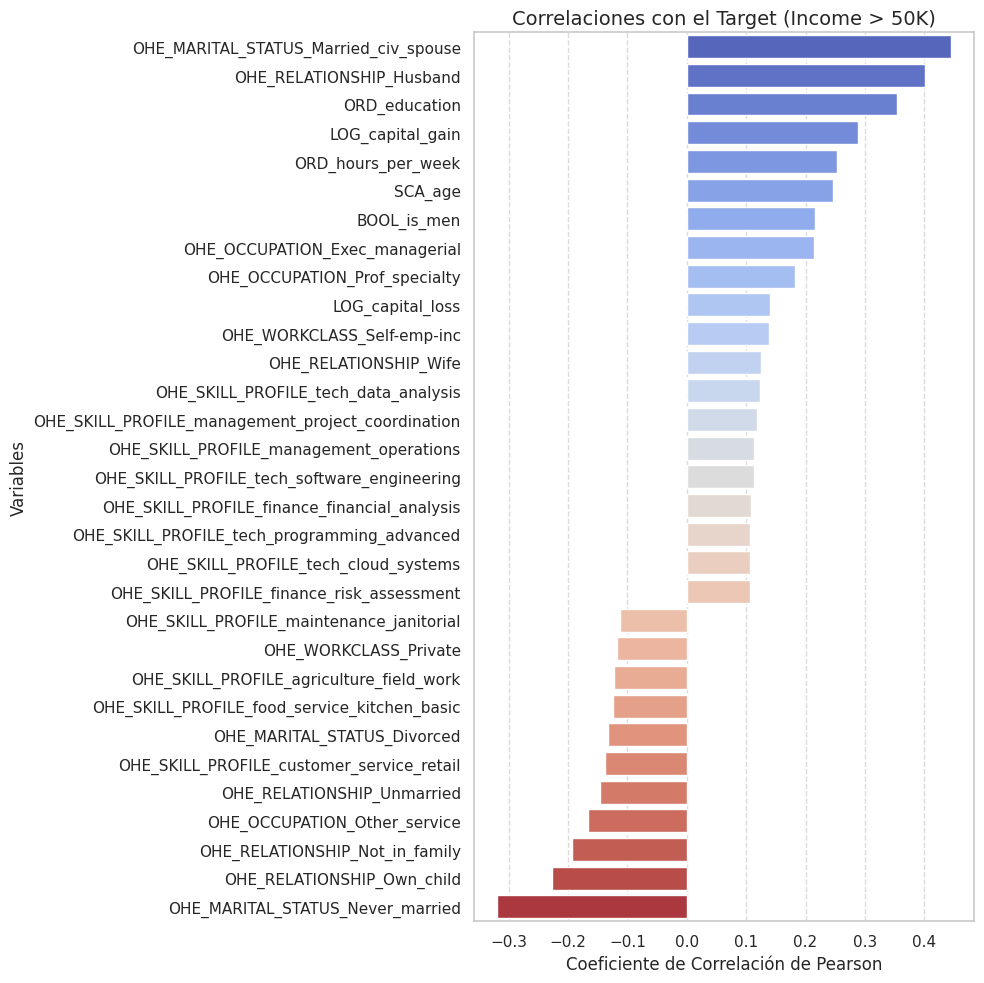

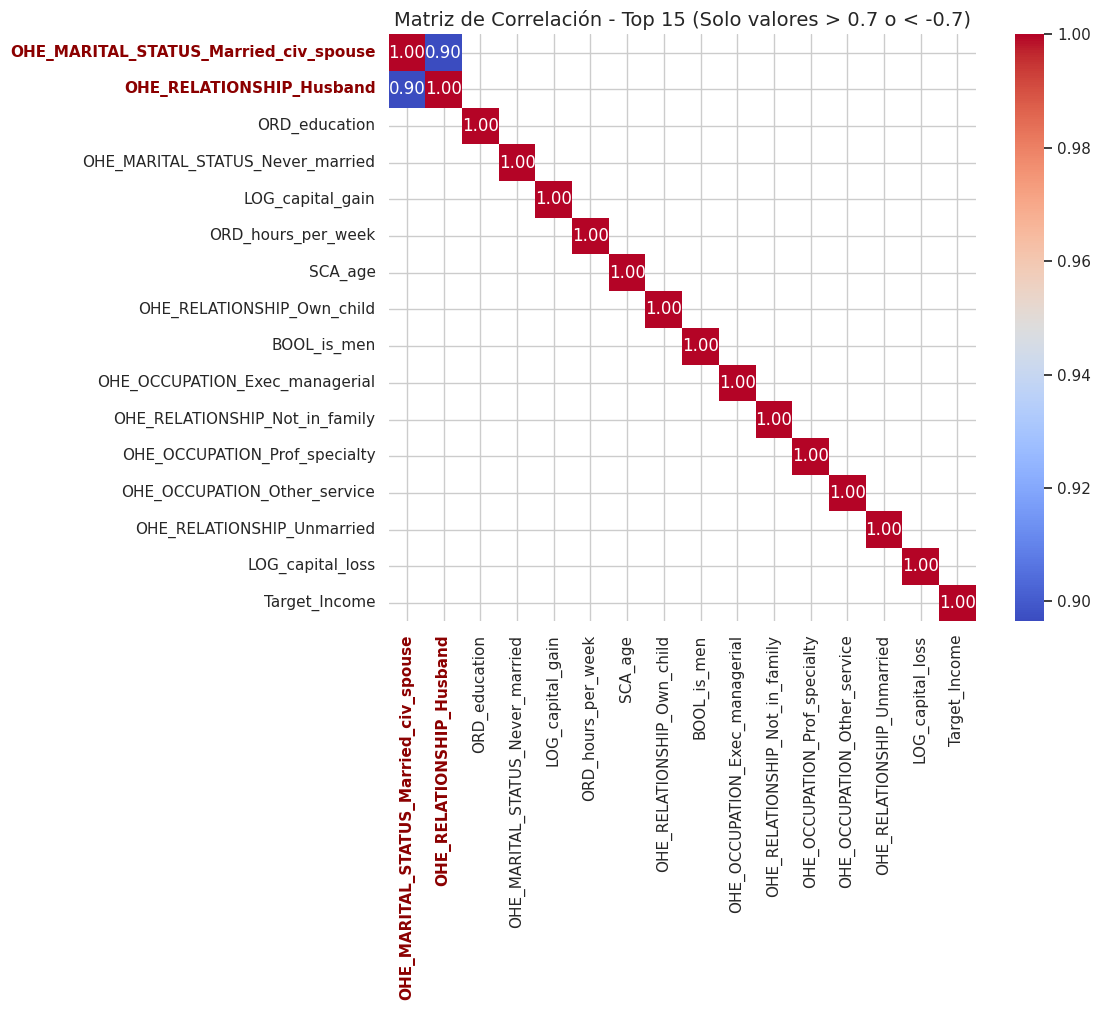

In [43]:
# 1. Unir X_train y y_train temporalmente para calcular la correlación
df_corr = X_train.copy()
df_corr['Target_Income'] = y_train

# Calcular la matriz de correlación de Pearson
corr_matrix = df_corr.corr()

# 2. Extraer la correlación de todas las variables con respecto al Target
target_corr = corr_matrix['Target_Income'].drop('Target_Income').sort_values(ascending=False)

# Filtrar: solo mostrar correlaciones <= -0.1 o >= 0.1
target_corr_filtered = target_corr[(target_corr >= 0.1) | (target_corr <= -0.1)]

# Graficar la correlación con el Target (filtrada)
plt.figure(figsize=(10, 10))
sns.barplot(x=target_corr_filtered.values, y=target_corr_filtered.index, palette='coolwarm', hue=target_corr_filtered.index, legend=False)
plt.title('Correlaciones con el Target (Income > 50K)', fontsize=14)
plt.xlabel('Coeficiente de Correlación de Pearson', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Heatmap de correlación entre las top 15 variables más correlacionadas (en valor absoluto)
top_features = target_corr.abs().sort_values(ascending=False).head(15).index.tolist()
top_features.append('Target_Income') # Agregamos el target al final para el mapa

# Matriz de correlación reducida
corr_matrix_top = df_corr[top_features].corr()

# Crear máscara para ocultar correlaciones débiles (entre -0.7 y 0.7)
mask = (corr_matrix_top > -0.7) & (corr_matrix_top < 0.7)

# Identificar qué variables tienen al menos una correlación visible (excluyendo la diagonal)
mask_for_check = mask.copy()
np.fill_diagonal(mask_for_check.values, True) # Ignorar la diagonal
active_features = ~mask_for_check.all()

plt.figure(figsize=(12, 10))
ax = sns.heatmap(corr_matrix_top, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, mask=mask)
plt.title('Matriz de Correlación - Top 15 (Solo valores > 0.7 o < -0.7)', fontsize=14)

# Resaltar en rojo y negrita las etiquetas de las filas/columnas encendidas
for i, feature in enumerate(corr_matrix_top.columns):
    if active_features.iloc[i]:
        ax.get_xticklabels()[i].set_color('darkred')
        ax.get_xticklabels()[i].set_weight('bold')
        ax.get_yticklabels()[i].set_color('darkred')
        ax.get_yticklabels()[i].set_weight('bold')

plt.tight_layout()
plt.show()


In [44]:
# Dropeo variables altamente correlacionadas
to_drop = [
    "OHE_RELATIONSHIP_Husband"
]

# Y tambien droparemos a las que les vamos a aplicar Embeddings (Occupation y Skill-profile)
cols_to_drop_occ = [col for col in X_train.columns if 'OHE_OCCUPATION' in col]
cols_to_drop_skill = [col for col in X_train.columns if 'OHE_SKILL_PROFILE' in col]

to_drop.extend(cols_to_drop_occ)
to_drop.extend(cols_to_drop_skill)

X_train = X_train.drop(columns=to_drop, errors='ignore')
X_test = X_test.drop(columns=to_drop, errors='ignore')


In [45]:
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Total de features: {X_train.shape[1]}")

Dimensiones de X_train: (30162, 31)
Dimensiones de X_test: (15060, 31)
Total de features: 31


## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

### Generacion de Embeddings

#### Occupation

In [46]:
# Preparación de la variable Occupation para Embeddings
occ_train_raw = train['occupation'].astype(str)
occ_test_raw = test['occupation'].astype(str)

# Obtener categorías únicas y crear diccionario de mapeo
unique_occ = occ_train_raw.unique()
occ_to_idx = {occ: idx for idx, occ in enumerate(unique_occ)}

# Aplicar mapeo a los conjuntos de datos
occ_train_idx = occ_train_raw.map(occ_to_idx).fillna(0).astype(int).values
occ_test_idx = occ_test_raw.map(occ_to_idx).fillna(0).astype(int).values

# Convertir a tensores de PyTorch (tipo Long para Embeddings)
occ_train_tensor = torch.tensor(occ_train_idx, dtype=torch.long)
occ_test_tensor = torch.tensor(occ_test_idx, dtype=torch.long)

# Definir la capa de Embedding
num_cat_occ = len(unique_occ)
# embedding_dim_occ = max(1, int(num_cat_occ ** 0.5)) # Visto en clase
# embedding_dim_occ = min(600, (num_cat_occ // 2) + 1) # Fast AI V1
embedding_dim_occ = min(600, round(1.6 * num_cat_occ ** 0.56)) # Fast AI V2

embedding_layer_occ = nn.Embedding(num_embeddings=num_cat_occ, embedding_dim=embedding_dim_occ)

print(f"Cardinalidad de Occupation: {num_cat_occ}")
print(f"Dimensión del Embedding para Occupation: {embedding_dim_occ}")

Cardinalidad de Occupation: 14
Dimensión del Embedding para Occupation: 7


#### Skill-Profile

In [47]:
# Preparación de la variable Skill-profile para Embeddings
skill_train_raw = train['skill-profile'].astype(str)
skill_test_raw = test['skill-profile'].astype(str)

# Obtener categorías únicas y crear diccionario de mapeo
unique_skill = skill_train_raw.unique()
skill_to_idx = {sk: idx for idx, sk in enumerate(unique_skill)}

# Aplicar mapeo a los conjuntos de datos
skill_train_idx = skill_train_raw.map(skill_to_idx).fillna(0).astype(int).values
skill_test_idx = skill_test_raw.map(skill_to_idx).fillna(0).astype(int).values

# Convertir a tensores de PyTorch (tipo Long para Embeddings)
skill_train_tensor = torch.tensor(skill_train_idx, dtype=torch.long)
skill_test_tensor = torch.tensor(skill_test_idx, dtype=torch.long)

# Definir la capa de Embedding
num_cat_skill = len(unique_skill)
# embedding_dim_skill = max(1, int(num_cat_skill ** 0.5)) # Visto en clase
# embedding_dim_skill = min(600, (num_cat_skill // 2) + 1) # Fast AI V1
embedding_dim_skill = min(600, round(1.6 * num_cat_skill ** 0.56)) # Fast AI V2

embedding_layer_skill = nn.Embedding(num_embeddings=num_cat_skill, embedding_dim=embedding_dim_skill)

print(f"Cardinalidad de Skill-profile: {num_cat_skill}")
print(f"Dimensión del Embedding para Skill-profile: {embedding_dim_skill}")

Cardinalidad de Skill-profile: 80
Dimensión del Embedding para Skill-profile: 19


- Regla empírica (raíz cuadrada de la cardinalidad)

### Preparacion de los Tensores

In [48]:
# 1. Convertir los datos a tensores de PyTorch
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# 2. Crear DataLoaders para manejar los lotes (batches), incluyendo los tensores categóricos
batch_size = 64

train_dataset = TensorDataset(X_train_tensor, occ_train_tensor, skill_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, occ_test_tensor, skill_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Tamaño del lote: {batch_size}")
print(f"Cantidad de batches en train: {len(train_loader)}")
print(f"Features continuos de entrada: {X_train.shape[1]}")

Tamaño del lote: 64
Cantidad de batches en train: 472
Features continuos de entrada: 31


### Split de la base

In [49]:
# 1. Separar un conjunto de validación del de entrenamiento (80% train, 20% val)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_tensor, y_train_tensor, test_size=0.2, random_state=42, stratify=y_train_tensor
)

print(f"Tamaño de Train (Split): {X_train_split.shape[0]}")
print(f"Tamaño de Validación: {X_val_split.shape[0]}")
print(f"Tamaño de Test (Intacto): {X_test_tensor.shape[0]}")

# 2. Actualizar los DataLoaders
batch_size = 256

train_dataset_split = TensorDataset(X_train_split, y_train_split)
train_loader_split = DataLoader(train_dataset_split, batch_size=batch_size, shuffle=True)

val_dataset_split = TensorDataset(X_val_split, y_val_split)
val_loader_split = DataLoader(val_dataset_split, batch_size=batch_size, shuffle=False)

# test_loader ya estaba creado y no se modifica


Tamaño de Train (Split): 24129
Tamaño de Validación: 6033
Tamaño de Test (Intacto): 15060


### Arquitectura de la NN

In [50]:
class BaselineNN(nn.Module):
    def __init__(self, input_dim):
        super(BaselineNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train_tensor.shape[1]
model_baseline = BaselineNN(input_dim)
print(model_baseline)


BaselineNN(
  (network): Sequential(
    (0): Linear(in_features=31, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


### Entrenamiento de la NN

In [51]:
# 4. Configurar Loss y Optimizador con learning rate ajustado
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_baseline.parameters(), lr=0.001)

# 5. Ciclo de Entrenamiento con Early Stopping (usando el set de validación)
# Valores coherentes para un baseline rápido
epochs = 400
patience = 20
best_val_loss = float('inf')
epochs_no_improve = 0

# Aquí guardaremos los pesos del MEJOR modelo, garantizando no devolver el de la última época
best_model_wts = copy.deepcopy(model_baseline.state_dict())

# Variables para guardar las métricas de la mejor época
best_epoch = 0
best_train_loss = 0.0
best_train_f1 = 0.0
best_val_f1 = 0.0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_f1_macros, val_f1_macros = [], []

print("Iniciando entrenamiento del Baseline NN con set de validación...")
for epoch in range(epochs):
    # --- TRAIN ---
    model_baseline.train()
    batch_losses = []
    correct_train = 0
    total_train = 0
    all_preds_train = []
    all_labels_train = []

    for X_batch, y_batch in train_loader_split:
        optimizer.zero_grad()
        outputs = model_baseline(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct_train += (preds == y_batch).sum().item()
        total_train += y_batch.size(0)

        all_preds_train.extend(preds.cpu().numpy())
        all_labels_train.extend(y_batch.cpu().numpy())

    train_losses.append(np.mean(batch_losses))
    train_accuracies.append(correct_train / total_train)
    train_f1_macros.append(f1_score(all_labels_train, all_preds_train, average='macro'))

    # --- VALIDATION ---
    model_baseline.eval()
    batch_losses_val = []
    correct_val = 0
    total_val = 0
    all_preds_val = []
    all_labels_val = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader_split:
            outputs = model_baseline(X_batch)
            loss = criterion(outputs, y_batch)
            batch_losses_val.append(loss.item())

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct_val += (preds == y_batch).sum().item()
            total_val += y_batch.size(0)

            all_preds_val.extend(preds.cpu().numpy())
            all_labels_val.extend(y_batch.cpu().numpy())

    current_val_loss = np.mean(batch_losses_val)
    val_losses.append(current_val_loss)
    val_accuracies.append(correct_val / total_val)
    val_f1_macros.append(f1_score(all_labels_val, all_preds_val, average='macro'))

    # --- EARLY STOPPING CHECK ---
    # Si mejoramos la validación, guardamos una copia de los pesos actuales como los mejores
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_model_wts = copy.deepcopy(model_baseline.state_dict())
        epochs_no_improve = 0

        # Guardamos los valores de esta mejor época
        best_epoch = epoch + 1
        best_train_loss = train_losses[-1]
        best_train_f1 = train_f1_macros[-1]
        best_val_f1 = val_f1_macros[-1]
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 5 == 0 or epoch == 0 or epochs_no_improve >= patience:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {train_losses[-1]:.4f} - F1: {train_f1_macros[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} - F1: {val_f1_macros[-1]:.4f}")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping disparado en la época {epoch+1}.")
        print(f"Restaurando los MEJORES pesos (de la época {best_epoch}) -> Train Loss: {best_train_loss:.4f} - F1: {best_train_f1:.4f} | Val Loss: {best_val_loss:.4f} - F1: {best_val_f1:.4f}")
        # Restauración efectiva para garantizar que se devuelve el mejor modelo
        model_baseline.load_state_dict(best_model_wts)
        break


Iniciando entrenamiento del Baseline NN con set de validación...
Epoch 001/400 | Train Loss: 0.5289 - F1: 0.5132 | Val Loss: 0.3793 - F1: 0.7418
Epoch 005/400 | Train Loss: 0.3557 - F1: 0.7636 | Val Loss: 0.3445 - F1: 0.7710
Epoch 010/400 | Train Loss: 0.3448 - F1: 0.7712 | Val Loss: 0.3425 - F1: 0.7657
Epoch 015/400 | Train Loss: 0.3422 - F1: 0.7722 | Val Loss: 0.3383 - F1: 0.7715
Epoch 020/400 | Train Loss: 0.3394 - F1: 0.7750 | Val Loss: 0.3366 - F1: 0.7697
Epoch 025/400 | Train Loss: 0.3384 - F1: 0.7763 | Val Loss: 0.3365 - F1: 0.7724
Epoch 030/400 | Train Loss: 0.3364 - F1: 0.7773 | Val Loss: 0.3376 - F1: 0.7647
Epoch 035/400 | Train Loss: 0.3340 - F1: 0.7764 | Val Loss: 0.3350 - F1: 0.7741
Epoch 040/400 | Train Loss: 0.3337 - F1: 0.7817 | Val Loss: 0.3338 - F1: 0.7671
Epoch 045/400 | Train Loss: 0.3300 - F1: 0.7848 | Val Loss: 0.3339 - F1: 0.7694
Epoch 050/400 | Train Loss: 0.3286 - F1: 0.7846 | Val Loss: 0.3350 - F1: 0.7651
Epoch 055/400 | Train Loss: 0.3258 - F1: 0.7864 | Val L

- BCEWithLogitsLoss porque es un problema de Clasificacion Binaria

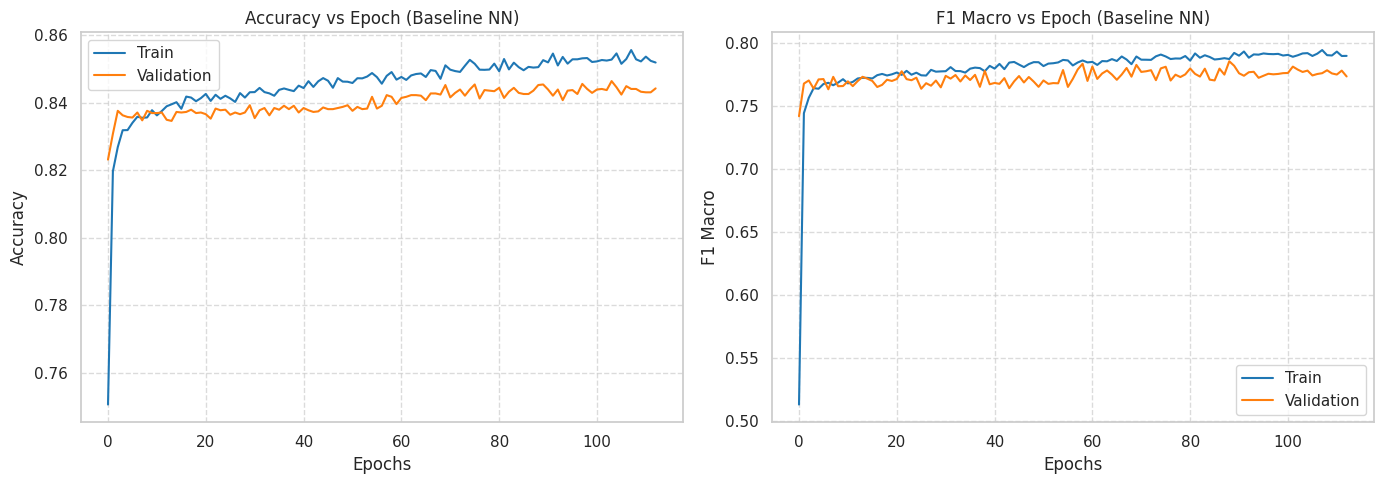

In [52]:
# 6. Graficar las curvas de entrenamiento: Accuracy y F1 Macro
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Definir colores consistentes
color_train = '#1f77b4'  # Azul
color_val = '#ff7f0e'    # Naranja

# Accuracy vs Epoch
axes[0].plot(train_accuracies, label='Train', color=color_train)
axes[0].plot(val_accuracies, label='Validation', color=color_val)
axes[0].set_title('Accuracy vs Epoch (Baseline NN)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# F1 Macro vs Epoch
axes[1].plot(train_f1_macros, label='Train', color=color_train)
axes[1].plot(val_f1_macros, label='Validation', color=color_val)
axes[1].set_title('F1 Macro vs Epoch (Baseline NN)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('F1 Macro')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Evaluacion de la NN en set de Validacion

--- Classification Report (Set de Validación) ---
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      4531
        >50K       0.73      0.59      0.65      1502

    accuracy                           0.84      6033
   macro avg       0.80      0.76      0.78      6033
weighted avg       0.84      0.84      0.84      6033



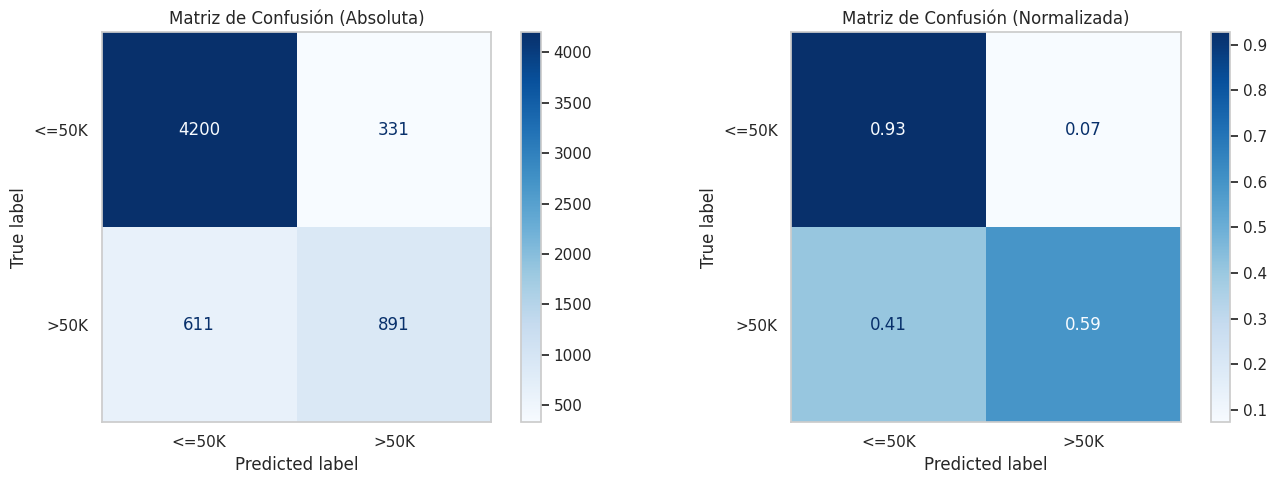

In [53]:
# 7. Evaluación final en el set de Validación
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Asegurarnos de que el modelo esté en modo evaluación
model_baseline.eval()
all_preds_val_final = []
all_labels_val_final = []

with torch.no_grad():
    for X_batch, y_batch in val_loader_split:
        outputs = model_baseline(X_batch)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        all_preds_val_final.extend(preds.cpu().numpy())
        all_labels_val_final.extend(y_batch.cpu().numpy())

print("--- Classification Report (Set de Validación) ---")
print(classification_report(all_labels_val_final, all_preds_val_final, target_names=['<=50K', '>50K']))

# Generar matrices de confusión
cm_abs = confusion_matrix(all_labels_val_final, all_preds_val_final)
cm_norm = confusion_matrix(all_labels_val_final, all_preds_val_final, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión Absoluta
disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm_abs, display_labels=['<=50K', '>50K'])
disp_abs.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Matriz de Confusión (Absoluta)')
axes[0].grid(False)

# Matriz de Confusión Normalizada por fila
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['<=50K', '>50K'])
disp_norm.plot(cmap='Blues', ax=axes[1], values_format='.2f')
axes[1].set_title('Matriz de Confusión (Normalizada)')
axes[1].grid(False)

plt.tight_layout()
plt.show()

### Evaluación de la NN en el set de Test

--- Classification Report (Set de TEST) ---
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90     11360
        >50K       0.73      0.59      0.65      3700

    accuracy                           0.84     15060
   macro avg       0.80      0.76      0.78     15060
weighted avg       0.84      0.84      0.84     15060



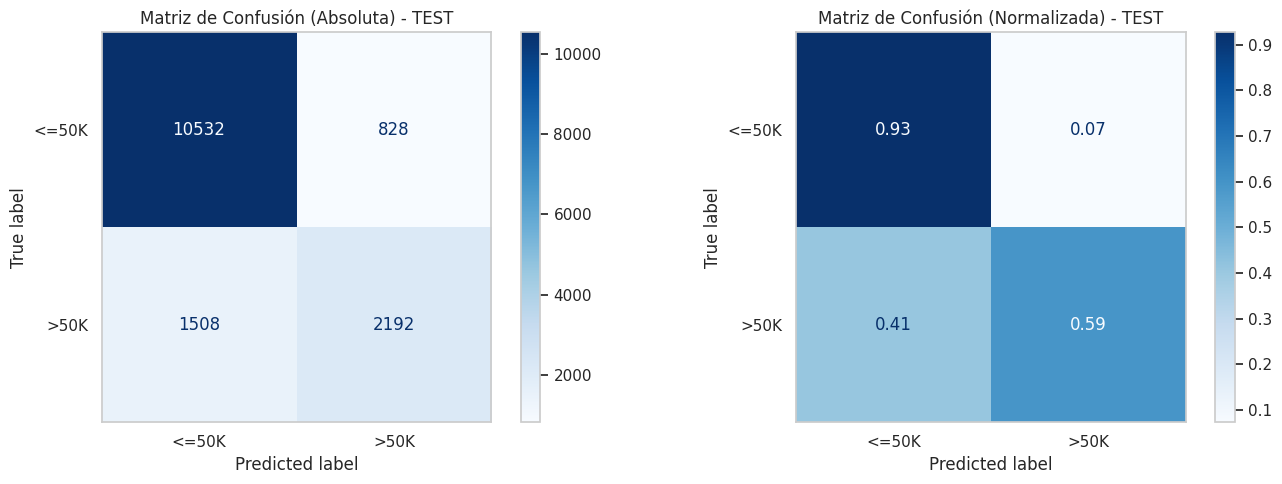

In [54]:
# Asegurarnos de que el modelo esté en modo evaluación
model_baseline.eval()
all_preds_test = []
all_labels_test = []

with torch.no_grad():
    for X_batch, occ_batch, skill_batch, y_batch in test_loader:
        outputs = model_baseline(X_batch)
        # Aplicar sigmoide y umbral de 0.5 para la clasificación binaria
        preds = (torch.sigmoid(outputs) >= 0.5).float()

        all_preds_test.extend(preds.cpu().numpy())
        all_labels_test.extend(y_batch.cpu().numpy())

print("--- Classification Report (Set de TEST) ---")
print(classification_report(all_labels_test, all_preds_test, target_names=['<=50K', '>50K']))

# Matrices de Confusión para Test
cm_abs_test = confusion_matrix(all_labels_test, all_preds_test)
cm_norm_test = confusion_matrix(all_labels_test, all_preds_test, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión Absoluta
disp_abs_test = ConfusionMatrixDisplay(confusion_matrix=cm_abs_test, display_labels=['<=50K', '>50K'])
disp_abs_test.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Matriz de Confusión (Absoluta) - TEST')
axes[0].grid(False)

# Matriz de Confusión Normalizada por fila
disp_norm_test = ConfusionMatrixDisplay(confusion_matrix=cm_norm_test, display_labels=['<=50K', '>50K'])
disp_norm_test.plot(cmap='Blues', ax=axes[1], values_format='.2f')
axes[1].set_title('Matriz de Confusión (Normalizada) - TEST')
axes[1].grid(False)

plt.tight_layout()
plt.show()

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

In [56]:
print("-" * 50)
print("PREPARANDO MODELO SIN EMBEDDINGS (PUNTO C)")
print("-" * 50)

# 1. Preparar los datos con OHE para Occupation y Skill-profile
X_train_c = pd.concat([X_train, OHE_occupation_train, OHE_skill_profile_train], axis=1)
X_test_c = pd.concat([X_test, OHE_occupation_test, OHE_skill_profile_test], axis=1)

# Convertir a tensores
X_train_tensor_c = torch.tensor(X_train_c.values, dtype=torch.float32)
X_test_tensor_c = torch.tensor(X_test_c.values, dtype=torch.float32)
# y_train_tensor e y_test_tensor ya existen del punto anterior

# Separar en train y val con el mismo random_state y proporción que el punto B
X_train_split_c, X_val_split_c, y_train_split_c, y_val_split_c = train_test_split(
    X_train_tensor_c, y_train_tensor, test_size=0.2, random_state=42, stratify=y_train_tensor
)

# 2. Crear los nuevos DataLoaders (solo X e y, ya no mandamos tensores categóricos)
batch_size = 256

train_dataset_c = TensorDataset(X_train_split_c, y_train_split_c)
train_loader_c = DataLoader(train_dataset_c, batch_size=batch_size, shuffle=True)

val_dataset_c = TensorDataset(X_val_split_c, y_val_split_c)
val_loader_c = DataLoader(val_dataset_c, batch_size=batch_size, shuffle=False)

test_dataset_c = TensorDataset(X_test_tensor_c, y_test_tensor)
test_loader_c = DataLoader(test_dataset_c, batch_size=batch_size, shuffle=False)

print(f"Dimensiones de entrada final (Features): {X_train_tensor_c.shape[1]}")

--------------------------------------------------
PREPARANDO MODELO SIN EMBEDDINGS (PUNTO C)
--------------------------------------------------
Dimensiones de entrada final (Features): 125


In [57]:
# 3. Definir modelo SIN embeddings y SIN Dropout, con misma arquitectura base
class NNOHE_NoDropout(nn.Module):
    def __init__(self, input_dim):
        super(NNOHE_NoDropout, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            # SIN DROPOUT
            nn.Linear(64, 32),
            nn.ReLU(),
            # SIN DROPOUT
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

input_dim_c = X_train_tensor_c.shape[1]
model_c = NNOHE_NoDropout(input_dim_c)
print(model_c)

NNOHE_NoDropout(
  (network): Sequential(
    (0): Linear(in_features=125, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [58]:
# 4. Configurar Loss y Optimizador
criterion_c = nn.BCEWithLogitsLoss()
optimizer_c = optim.Adam(model_c.parameters(), lr=0.001)

# 5. Ciclo de Entrenamiento
epochs = 400
patience = 20
best_val_loss_c = float('inf')
epochs_no_improve_c = 0
best_model_wts_c = copy.deepcopy(model_c.state_dict())

train_losses_c, val_losses_c = [], []
train_accuracies_c, val_accuracies_c = [], []
train_f1_macros_c, val_f1_macros_c = [], []

print("\n" + "-" * 50)
print("ENTRENANDO MODELO (SIN EMBEDDINGS, SIN DROPOUT)")
print("-" * 50)

for epoch in range(epochs):
    # --- TRAIN ---
    model_c.train()
    batch_losses = []
    correct_train = 0
    total_train = 0
    all_preds_train = []
    all_labels_train = []

    for X_batch, y_batch in train_loader_c:
        optimizer_c.zero_grad()
        outputs = model_c(X_batch)
        loss = criterion_c(outputs, y_batch)
        loss.backward()
        optimizer_c.step()

        batch_losses.append(loss.item())

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct_train += (preds == y_batch).sum().item()
        total_train += y_batch.size(0)

        all_preds_train.extend(preds.cpu().numpy())
        all_labels_train.extend(y_batch.cpu().numpy())

    train_losses_c.append(np.mean(batch_losses))
    train_accuracies_c.append(correct_train / total_train)
    train_f1_macros_c.append(f1_score(all_labels_train, all_preds_train, average='macro'))

    # --- VALIDATION ---
    model_c.eval()
    batch_losses_val = []
    correct_val = 0
    total_val = 0
    all_preds_val = []
    all_labels_val = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader_c:
            outputs = model_c(X_batch)
            loss = criterion_c(outputs, y_batch)
            batch_losses_val.append(loss.item())

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct_val += (preds == y_batch).sum().item()
            total_val += y_batch.size(0)

            all_preds_val.extend(preds.cpu().numpy())
            all_labels_val.extend(y_batch.cpu().numpy())

    current_val_loss = np.mean(batch_losses_val)
    val_losses_c.append(current_val_loss)
    val_accuracies_c.append(correct_val / total_val)
    val_f1_macros_c.append(f1_score(all_labels_val, all_preds_val, average='macro'))

    # --- EARLY STOPPING CHECK ---
    if current_val_loss < best_val_loss_c:
        best_val_loss_c = current_val_loss
        best_model_wts_c = copy.deepcopy(model_c.state_dict())
        epochs_no_improve_c = 0
    else:
        epochs_no_improve_c += 1

    if (epoch + 1) % 5 == 0 or epoch == 0 or epochs_no_improve_c >= patience:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {train_losses_c[-1]:.4f} - F1: {train_f1_macros_c[-1]:.4f} | Val Loss: {val_losses_c[-1]:.4f} - F1: {val_f1_macros_c[-1]:.4f}")

    if epochs_no_improve_c >= patience:
        print(f"\nEarly stopping disparado en la época {epoch+1}.")
        model_c.load_state_dict(best_model_wts_c)
        break


--------------------------------------------------
ENTRENANDO MODELO (SIN EMBEDDINGS, SIN DROPOUT)
--------------------------------------------------
Epoch 001/400 | Train Loss: 0.4851 - F1: 0.5639 | Val Loss: 0.3256 - F1: 0.8007
Epoch 005/400 | Train Loss: 0.2661 - F1: 0.8435 | Val Loss: 0.2701 - F1: 0.8369
Epoch 010/400 | Train Loss: 0.2592 - F1: 0.8481 | Val Loss: 0.2655 - F1: 0.8414
Epoch 015/400 | Train Loss: 0.2498 - F1: 0.8555 | Val Loss: 0.2696 - F1: 0.8354
Epoch 020/400 | Train Loss: 0.2426 - F1: 0.8580 | Val Loss: 0.2726 - F1: 0.8379
Epoch 025/400 | Train Loss: 0.2340 - F1: 0.8632 | Val Loss: 0.2821 - F1: 0.8287
Epoch 030/400 | Train Loss: 0.2305 - F1: 0.8687 | Val Loss: 0.2853 - F1: 0.8350

Early stopping disparado en la época 30.


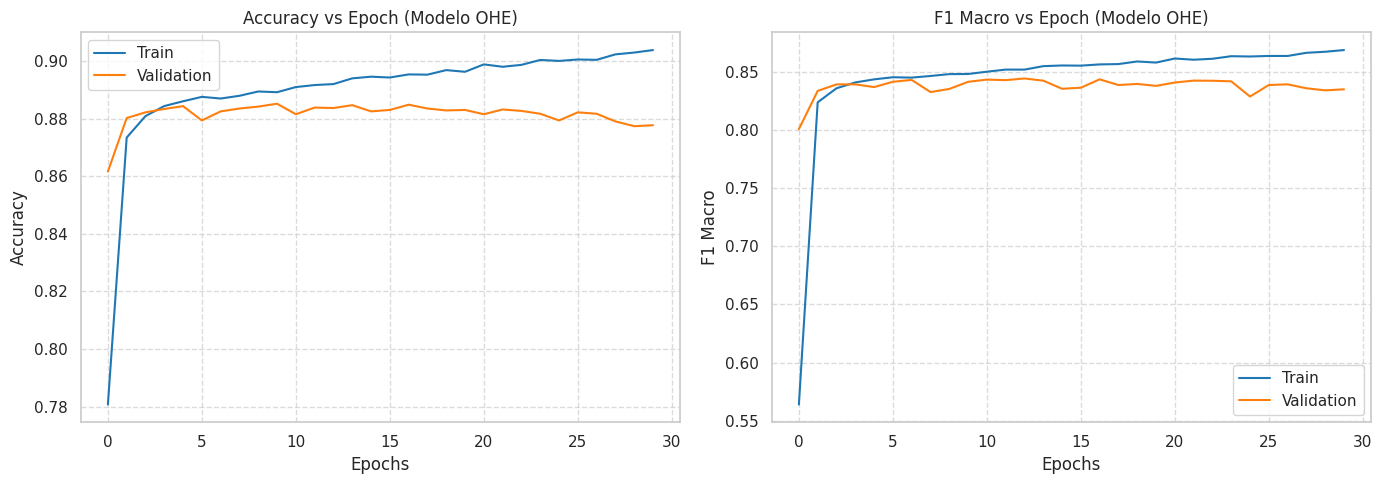

In [59]:
# 6. Graficar las curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
color_train, color_val = '#1f77b4', '#ff7f0e'

axes[0].plot(train_accuracies_c, label='Train', color=color_train)
axes[0].plot(val_accuracies_c, label='Validation', color=color_val)
axes[0].set_title('Accuracy vs Epoch (Modelo OHE)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].plot(train_f1_macros_c, label='Train', color=color_train)
axes[1].plot(val_f1_macros_c, label='Validation', color=color_val)
axes[1].set_title('F1 Macro vs Epoch (Modelo OHE)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('F1 Macro')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


--------------------------------------------------
EVALUACIÓN MODELO (PUNTO C) EN TEST
--------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.93     11360
        >50K       0.81      0.72      0.76      3700

    accuracy                           0.89     15060
   macro avg       0.86      0.83      0.84     15060
weighted avg       0.89      0.89      0.89     15060



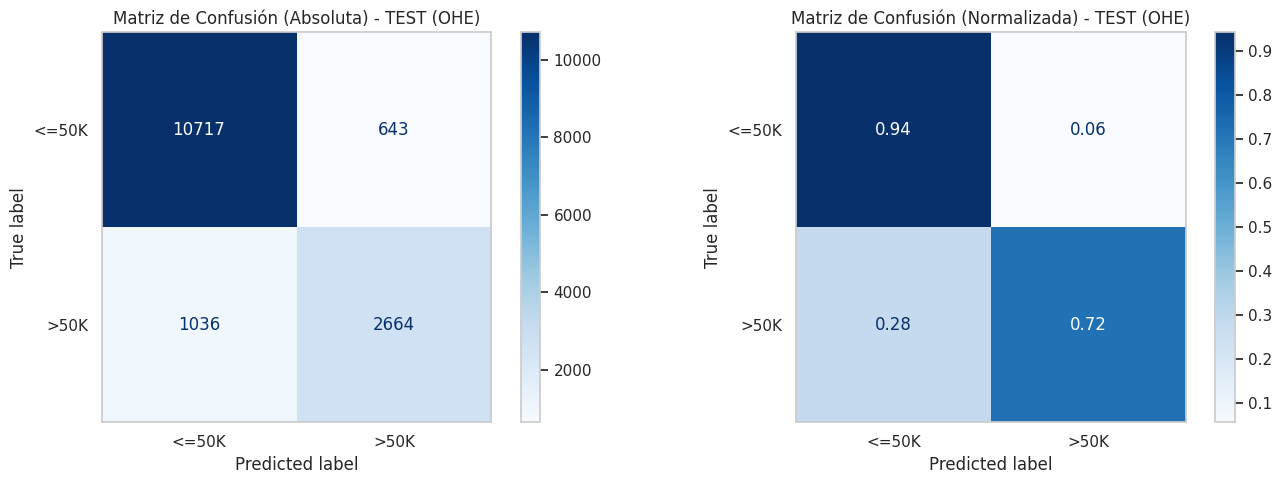

In [60]:
# 7. Evaluación en Test
print("\n" + "-" * 50)
print("EVALUACIÓN MODELO EN TEST")
print("-" * 50)
model_c.eval()
all_preds_test_c = []
all_labels_test_c = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_c:
        outputs = model_c(X_batch)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        all_preds_test_c.extend(preds.cpu().numpy())
        all_labels_test_c.extend(y_batch.cpu().numpy())

print(classification_report(all_labels_test_c, all_preds_test_c, target_names=['<=50K', '>50K']))

# Matrices de Confusión
cm_abs_c = confusion_matrix(all_labels_test_c, all_preds_test_c)
cm_norm_c = confusion_matrix(all_labels_test_c, all_preds_test_c, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Absoluta
disp_abs_c = ConfusionMatrixDisplay(confusion_matrix=cm_abs_c, display_labels=['<=50K', '>50K'])
disp_abs_c.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Matriz de Confusión (Absoluta) - TEST (OHE)')
axes[0].grid(False)

# Matriz Normalizada
disp_norm_c = ConfusionMatrixDisplay(confusion_matrix=cm_norm_c, display_labels=['<=50K', '>50K'])
disp_norm_c.plot(cmap='Blues', ax=axes[1], values_format='.2f')
axes[1].set_title('Matriz de Confusión (Normalizada) - TEST (OHE)')
axes[1].grid(False)

plt.tight_layout()
plt.show()


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.

In [ ]:
# def count_parameters(model):
#     return sum(p.numel() for p in model.parameters() if p.requires_grad)

# params_emb = count_parameters(model_3emb)
# params_ohe = count_parameters(model_c)

# # Crear tabla comparativa con pandas
# tabla_comparativa = pd.DataFrame({
#     'Métrica / Característica': [
#         'Dimensión de Entrada (Features al Forward)',
#         'Cantidad Total de Parámetros',
#         'Uso de Dropout',
#         'Época de Early Stopping',
#         'Accuracy (Test)',
#         'F1 Macro (Test)',
#         'Precision Clase >50K',
#         'Recall Clase >50K'
#     ],
#     'Modelo con Embeddings (Punto B)': [
#         f"{X_train_cont_3.shape[1]} (Cont.) + 3 (Categóricos)",
#         params_emb,
#         'Sí (0.3)',
#         '108',
#         '0.89',
#         '0.84',
#         '0.80',
#         '0.72'
#     ],
#     'Modelo OHE sin Dropout (Punto C)': [
#         str(X_train_c.shape[1]),
#         params_ohe,
#         'No',
#         '56',
#         '0.89',
#         '0.84',
#         '0.81',
#         '0.72'
#     ]
# })

# display(tabla_comparativa.style.set_caption("Comparación de Modelos: Embeddings vs. OHE").set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}]))

### Observaciones y Conclusiones Finales

Al analizar la tabla comparativa y los resultados experimentales de ambos enfoques, se pueden destacar las siguientes conclusiones:

1. **Desempeño y Capacidad de Generalización (Métricas):**
   Ambos modelos alcanzaron métricas virtualmente idénticas en el conjunto de Test (Accuracy ~0.89 y F1 Macro ~0.84). Esto indica que, para la complejidad particular de este problema, ambas formas de representar la información logran extraer patrones predictivos con la misma eficacia.

2. **Dimensionalidad y Parámetros:**
   * El modelo con **OHE** genera una capa de entrada mucho más ancha (141 features) debido a la expansión de dimensionalidad al convertir categóricas como *Skill-profile* (80 categorías). Esto se traduce en más de 2500 parámetros concentrados principalmente en la primera capa oculta.
   * El modelo con **Embeddings**, por el contrario, requiere muchos más parámetros para construir sus matrices de representación latente, sumando un total aproximado de ~5100 parámetros en toda la red.

3. **Elección del Enfoque Ideal:**
   Para este caso de estudio, donde las variables categóricas (incluso la de mayor cardinalidad) no alcanzan números extremos de miles de categorías, **el modelo con One-Hot Encoding resulta más práctico y eficiente**. Brinda exactamente el mismo nivel predictivo, pero con la ventaja de ser computacionalmente más ligero y converger mucho más rápido durante el entrenamiento (el Early Stopping se activó en la época 56 para OHE vs la 108 para el modelo de Embeddings). El uso de Embeddings estaría plenamente justificado si la cardinalidad fuera inmanejable para OHE o si las variables tuvieran una riqueza semántica oculta fundamental para el problema.